### Business Object:

The objective of this assignment is to develop a machine learning model, based on the customer level data of a leading telecom firm, so as to identify customers whose probability of churn is high.  This will help the company in identifying the main drivers for customer churn and thus help them in retaining high value profitable customers. High value profitable customers are typically top 20% customers, who contribute 80% of the revenue to the telecom company. The business objective is to predict the churn in this segment by analyzing dataset for 3 months (i.e., June, July and August) and then based on this infromation predict the churn probability for the month of September.   

### Approches for Problem Solving:

This is a typical classification problem, where follwing steps will be performed to arrive at the solution

1. Perform EDA
2. Understanding Data Cleaning activities that need to be done
3. Feature Selection 
4. Feature extraction 
5. Model building 
6. Model evaluation 
7. Conclude model and final comments

In [4]:
# Importing required libraries 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# modeling related libs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.decomposition import IncrementalPCA
# from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# tree review
from IPython.display import Image  
from sklearn.externals.six import StringIO  
from sklearn.tree import export_graphviz
import pydotplus, graphviz
from sklearn.metrics import classification_report



# models library 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import  AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC



import os
import warnings
warnings.filterwarnings('ignore')


# defualt options for notebook and visuals 
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
%matplotlib inline 

# additional enablers
from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))

data_file =pd.read_csv("D:/telecom_churn_data.csv")
data_file.head()

#Documents/DS/ML_5(ML2 Group Assignment)/Data/telecom_churn_data.csv

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,214.816,213.803,21.100,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0.16,NaN,NaN,NaN,4.13,NaN,NaN,NaN,1.15,NaN,NaN,NaN,5.44,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,0.00,0.00,5.44,0.00,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,4,3,

In [5]:
# Utlity Library
class EstimatorSelectionHelper:

    def __init__(self, models, params):
        
        if not set(models.keys()).issubset(set(params.keys())):
            missing_params = list(set(models.keys()) - set(params.keys()))
            raise ValueError("Some estimators are missing parameters: %s" % missing_params)
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv=5, n_jobs=3, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print("Running GridSearchCV for %s." % key)
            model = self.models[key]
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, refit=refit,
                              return_train_score=True)
            gs.fit(X,y)
            self.grid_searches[key] = gs    

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                 'estimator': key,
                 'min_score': min(scores),
                 'max_score': max(scores),
                 'mean_score': np.mean(scores),
                 'std_score': np.std(scores),
            }
            return pd.Series({**params,**d})

        rows = []
        for k in self.grid_searches:
            print(k)
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]        
                scores.append(r.reshape(len(params),1))

            all_scores = np.hstack(scores)
            for p, s in zip(params,all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values("std_score").sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns]
    
   

In [10]:
# Utlity function 

def utility_missing_values(DS):
    _missing = DS.isnull().sum(axis=0)
    _missing = pd.DataFrame(_missing)
    _missing.columns=["MissingCount"]
    _missing["Missing_per"] = round(_missing.MissingCount /  DS_original.shape[0],2)
    return _missing

def Cleaned_routine(step): # initial cleaned routine
    DS_EDA = DS_original.copy()
    
    #Deleteing missing values over 50%
    if step >=1:
        
        DS_EDA.drop(DS_EDA[DS_EDA.isnull().sum(axis=1)>=100].index,inplace =True)
        DS_EDA.drop(['date_of_last_rech_data_6', 'max_rech_data_6', 'fb_user_6', 'night_pck_user_6', 'arpu_2g_6', 'arpu_3g_6',
                 'count_rech_3g_6', 'count_rech_2g_6', 'av_rech_amt_data_6', 'total_rech_data_6', 'max_rech_data_7', 'arpu_3g_7',
                 'fb_user_8', 'fb_user_7', 'date_of_last_rech_data_8', 'night_pck_user_9', 'night_pck_user_8', 'night_pck_user_7',
                 'date_of_last_rech_data_9', 'arpu_2g_9', 'arpu_2g_8', 'arpu_2g_7', 'arpu_3g_9', 'arpu_3g_8', 'total_rech_data_7',
                 'max_rech_data_8', 'av_rech_amt_data_9', 'av_rech_amt_data_8', 'av_rech_amt_data_7', 'date_of_last_rech_data_7',
                 'count_rech_3g_9', 'count_rech_3g_8', 'count_rech_3g_7', 'total_rech_data_8', 'count_rech_2g_9', 'count_rech_2g_8',
                 'count_rech_2g_7', 'total_rech_data_9', 'max_rech_data_9', 'fb_user_9'],axis=1,inplace =True)
    
    #based on action code removal of churned prior to September.
    
    if step >=2: 
        DS_EDA.drop(DS_EDA[DS_EDA.last_date_of_month_7.isnull()].index,axis=0,inplace =True)
        DS_EDA.drop(DS_EDA[DS_EDA.last_date_of_month_8.isnull()].index,axis=0,inplace =True)
        
    if step >=3:
        _list_columns = [i for i in DS_EDA.columns if "mou" in i]
        DS_EDA[_list_columns]=DS_EDA[_list_columns].fillna(0)
    if step >=4:
        _missing = utility_missing_values(DS_EDA)
        _cols = _missing[_missing.MissingCount >0].index 
        imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        DS_EDA[_cols]=imp.fit_transform(DS_EDA[_cols])
        
           
        
    return DS_EDA


In [7]:
# loading source data 
DS_original = pd.read_csv("D:/telecom_churn_data.csv")

printmd(f"#### Shape of original data set {DS_original.shape}")

print(DS_original.info(verbose=False))

display(DS_original.head(),DS_original.tail())


DS_original.describe()

#### Shape of original data set (99999, 226)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Columns: 226 entries, mobile_number to sep_vbc_3g
dtypes: float64(179), int64(35), object(12)
memory usage: 172.4+ MB
None


,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,214.816,213.803,21.100,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0.16,NaN,NaN,NaN,4.13,NaN,NaN,NaN,1.15,NaN,NaN,NaN,5.44,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,0.00,0.00,5.44,0.00,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,4,3,

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
99994,7001548952,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,18.471,69.161,57.530,29.950,5.40,3.36,5.91,0.00,15.19,54.46,52.79,27.14,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,5.40,3.36,5.91,0.00,12.78,54.46,49.58,24.78,0.00,0.00,0.00,2.25,0.00,0.0,3.21,0.11,18.18,57.83,55.49,27.03,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,2.41,3.01,3.21,0.11,0.00,0.0,0.0,0.0,20.59,60.84,58.71,27.14,27.68,20.78,40.94,22.06,47.96,46.93,76.08,82.89,17.45,5.16,43.79,49.46,93.09,72.88,160.83,154.43,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
count,9.999900e+04,99999.0,98981.0,98981.0,98981.0,99999.000000,99999.000000,99999.000000,99999.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.0,96140.0,94621.0,92254.0,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621

#####  Review 

    a. Data contains information for 99999 customers;
    b. We can visualize that a lot of columns have missing values;
    c. Vertical columns ending with a digit is typically denoting the respective month for which data is given; 
    d. Majority data is in the numerical form and some of the columns have null values;
    e. ARPU needs further investigation, as it has negative values in lower quartiles and very high values in >75th %ile;
    e. Only around 22 columns are represented as object format, like dates;
    f. Last_day* indicates the last day of the respective month.

In [8]:
# verify if data has any duplicates 
DS_original.duplicated().value_counts()

False    99999
dtype: int64

##### Review 

No duplicates found 

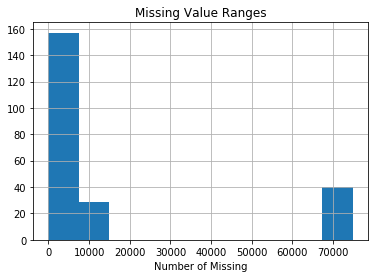

,MissingCount,Missing_per
date_of_last_rech_data_6,74846,0.75
max_rech_data_6,74846,0.75
fb_user_6,74846,0.75
night_pck_user_6,74846,0.75
arpu_2g_6,74846,0.75
arpu_3g_6,74846,0.75
count_rech_3g_6,74846,0.75
count_rech_2g_6,74846,0.75
av_rech_amt_data_6,74846,0.75
total_rech_data_6,74846,0.75


In [11]:
### Verify the missing values

_missing = utility_missing_values(DS_original)
plt.title("Missing Value Ranges")
_missing.MissingCount.hist()
plt.xlabel("Number of Missing")
plt.show()





_missing[_missing.Missing_per >0.5].sort_values(by="Missing_per",ascending=False)

##### Review 

Out of 226 columns, 166+ columns have missing values. Major inferences which can be drawn are:
- around 40+ columns have 70000 counts of missing values which comprises 70% of all data for a specific column;
- 160+ columns indicating missing values between 10000 and 15000 counts;
- we will investigate the reasons for the missing values and decide imputation stratagy, if required

In [12]:
## Delete all columns where we have missing values over 50%

#deleting will be done by cleaning function
DS_CLEAN = Cleaned_routine(step=1)

In [13]:
#Data Set having over 100 columns NA

DS_CLEAN[DS_CLEAN.isnull().sum(axis=1)>=100]

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g


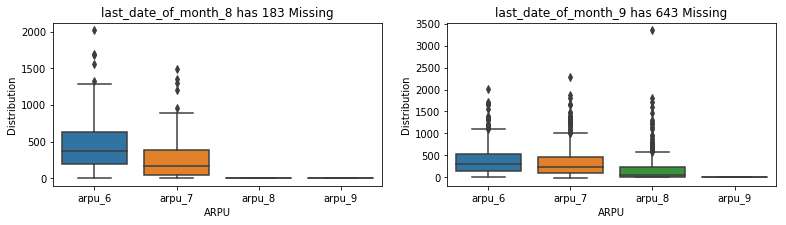

In [14]:
# understanding missing values 

def visual_na_relevence_arpu(primary_column):
    _temp=DS_CLEAN.loc[DS_CLEAN[primary_column].isnull(),["arpu_6","arpu_7","arpu_8","arpu_9"]].fillna(0)
    _i = _temp.shape[0]
    _temp=pd.melt(_temp,value_vars=['arpu_6','arpu_7','arpu_8','arpu_9'])
    # display plot
    sns.boxplot(x="variable", y="value", data=_temp)
    plt.title(primary_column + " has "+ str(_i) +" Missing")
    plt.xlabel("ARPU")
    plt.ylabel("Distribution")
    
plt.figure(figsize=(20,3))
#plt.subplot(1,3,1)
#visual_na_relevence_arpu("last_date_of_month_7") 

plt.subplot(1,3,2)
visual_na_relevence_arpu("last_date_of_month_8") 

plt.subplot(1,3,3)
visual_na_relevence_arpu("last_date_of_month_9")

### Review Summary

- Based on the above, we understand that if the value is NA on any of the last day of the month, we can consider that customer has terminated the relationship in the same month;
- Based on the above premise, we will remove those customer from the dataset, where they have terminated the relationship prior to September, in order to align our dataset with our objective

#### Actions 
- We will remove customers if they have missing value as on the last date of the month prior to September

In [15]:
# Delete rows if disconnected prior to Sep
DS_CLEAN = Cleaned_routine(step=2)

In [16]:
_missing = utility_missing_values(DS_CLEAN)

_missing[_missing.MissingCount >=1].sort_values(by="Missing_per",ascending=False)

,MissingCount,Missing_per
isd_og_mou_9,4869,0.05
loc_og_t2f_mou_9,4869,0.05
loc_og_t2t_mou_9,4869,0.05
std_og_t2f_mou_9,4869,0.05
std_ic_t2f_mou_9,4869,0.05
loc_og_t2m_mou_9,4869,0.05
loc_ic_t2t_mou_9,4869,0.05
std_ic_t2m_mou_9,4869,0.05
std_og_t2m_mou_9,4869,0.05
og_others_9,4869,0.05


#### Review comments 

Almost all the missing values are related to the Mou , minutes of usage, which we can safely replace with 0, based on the premise that null values denote zero usage.

In [17]:
# Fill Na with Zero

DS_CLEAN = Cleaned_routine(step=3)

In [18]:
_missing = utility_missing_values(DS_CLEAN)

_missing[_missing.MissingCount >=1].sort_values(by="Missing_per",ascending=False)

,MissingCount,Missing_per
og_others_9,4869,0.05
ic_others_9,4869,0.05
og_others_6,2640,0.03
og_others_8,2574,0.03
ic_others_6,2640,0.03
ic_others_8,2574,0.03
date_of_last_rech_9,2931,0.03
og_others_7,1610,0.02
ic_others_7,1610,0.02
date_of_last_rech_8,1893,0.02


In [19]:
# Impute missing values with the most freqent
DS_CLEAN = Cleaned_routine(step=4)

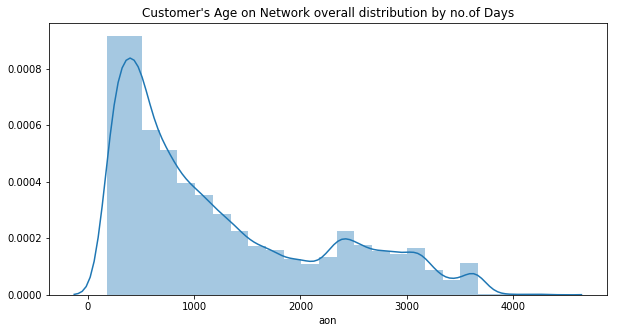

In [20]:
DS_CLEAN.head()

plt.figure(figsize=(10,5))
plt.title("Customer's Age on Network overall distribution by no.of Days")
sns.distplot(DS_CLEAN.aon,bins=25)
plt.show()

### Univariate & Bivariate Analysis

- Identify High value customers 
- Prepare target variable
- Conduct univariate analysis 
- Prepare target data set of high value customers 
- Analyse the correlation between dependent variables and target variables

In [22]:
# Identify the High Value customers

DS_CLEAN["recharge_good_phase"] =  (DS_CLEAN.total_rech_amt_6 + DS_CLEAN.total_rech_amt_7)/2
_per=np.percentile(DS_CLEAN.recharge_good_phase, 70)

DS_HH = DS_CLEAN[DS_CLEAN.recharge_good_phase >_per]

printmd(f"## 70% of Average Recharge is {_per}")

printmd(f"## Shape of High Value Customers {DS_HH.shape}")

# if sum of Incoming calls, Outgoing calls and Data consumption is zero, we can consider that customer as churned customer
DS_HH["Target"] = [1 if i ==0 else 0 for i in DS_HH[["total_ic_mou_9","total_og_mou_9","vol_2g_mb_9","vol_3g_mb_9"]].sum(axis=1)]

## Delete all churn phase related variables 

DS_HH=DS_HH.drop([i for i in DS_HH.columns if "_9" in i],axis=1)
                 
printmd(f"## Shape after identified churn {DS_HH.shape}")

## 70% of Average Recharge is 373.5

## Shape of High Value Customers (29091, 187)

## Shape after identified churn (29091, 144)

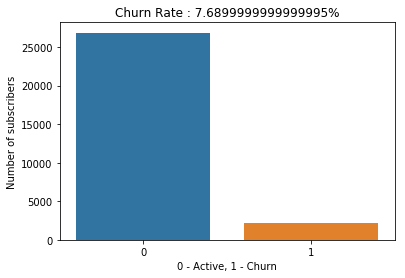

0    26853
1     2238
Name: Target, dtype: int64

In [23]:
### Univariate Analysis

plt.title(f"Churn Rate : { round(DS_HH[DS_HH.Target ==1].shape[0] / DS_HH.shape[0],4) *100 }%")
sns.countplot(DS_HH.Target)
plt.xlabel("0 - Active, 1 - Churn")
plt.ylabel("Number of subscribers")
plt.show()

DS_HH.Target.value_counts()

####  Review summary

##### Out of Total 29.6k customers, we could see 27k customers are active and 2.4k customers are churned customers

##### <font color="blue"> Churn rate is </font> <font color="red"> 8.17% </font>
    
<b> It clearly indicates that data set is inbalanced with the target variable we probably need to apply some sampling algorithm to balance the data set prior to modelling </b>

In [24]:
# Deleting mobile_number and circle_id as they will not add value to our results

DS_HH=DS_HH.drop(["mobile_number","circle_id"],axis=1)

### Non Numeric columns

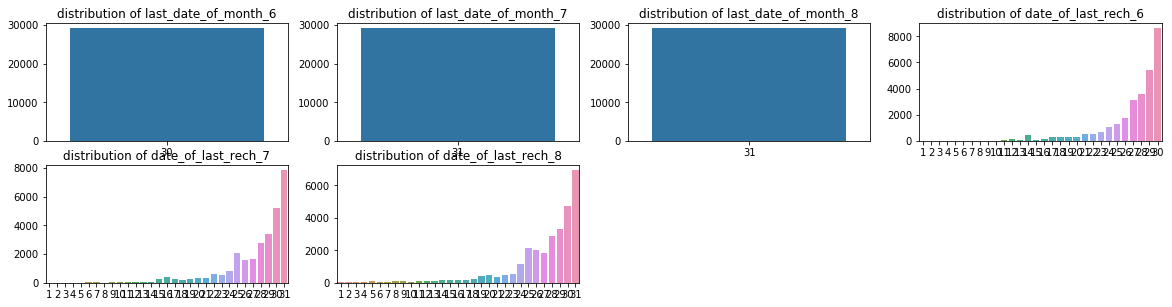

In [25]:
# Handling non numerical columns
_cols = DS_HH.select_dtypes(include=["object"]).columns
#DS_HH[_cols].T.gropup

plt.figure(figsize=(20,10))
printmd("### Non Numeric columns")
j=1

for i in _cols:
    plt.subplot(4,4,j)
    _temp=DS_HH[i].value_counts()
    _temp =_temp.reset_index()
    _temp.columns=["Date","Count"]
    _temp.Date=pd.to_datetime(_temp.Date)
    _temp["Date"] =_temp.Date.dt.day
    _temp=_temp.sort_values(by="Date")
    sns.barplot(data=_temp,x="Date",y="Count")
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f"distribution of {i}")
    j=j+1

### Review comments 

- We can clearly see that the first three graphs contains the last date of the month and do not explain any variation in this predictor variable; 
- The last three graphs shows the distribution for the date of last recharge and we can see that most of the customers prefer the end of the month to recharge their phone; 
- Based on the above conclusion, we can extract day from the datetime field and make it ordered categorical field, so as to undertand customer behavior with respect to recharge frequency during the month


In [26]:
# deleing date fields and convert last recharge date to last reacharge day
DS_HH=DS_HH.drop(["last_date_of_month_6","last_date_of_month_7","last_date_of_month_8"],axis=1)
DS_HH.date_of_last_rech_6 = pd.to_datetime(DS_HH.date_of_last_rech_6 ).dt.day
DS_HH.date_of_last_rech_7 = pd.to_datetime(DS_HH.date_of_last_rech_7 ).dt.day
DS_HH.date_of_last_rech_8 = pd.to_datetime(DS_HH.date_of_last_rech_8 ).dt.day

#### Review comments 

- We have now cleaned all non-numeric columns;
- Now the approch is to review columns through the VarianceThreshold method and we will delete all those columns where data is uniform and does not explain any variance.

In [27]:
DS_HH.shape

(29091, 139)

### Number of fields not explaining varience through VarianceThreshold

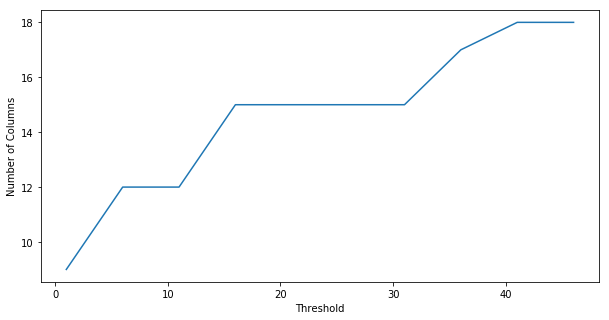

In [29]:
### Univariate Analysis
_temp = pd.DataFrame()

for i in range(1,50,5):
    var_threshold = VarianceThreshold(threshold=i/100)
    var_threshold.fit_transform(DS_HH.iloc[:,:-1].select_dtypes(exclude=["object"]))
    _cols=DS_HH.iloc[:,:-1].loc[:,~var_threshold.get_support()].shape[1]
    _dic = {"Threshold":i,"no_of_cols":_cols}
    _temp=_temp.append(_dic,ignore_index=True)

printmd("### Number of fields not explaining varience through VarianceThreshold")
plt.figure(figsize=(10,5))
sns.lineplot(data=_temp,y="no_of_cols",x="Threshold")
plt.ylabel("Number of Columns")
plt.xlabel("Threshold")
plt.show()

#### Review Comments 

- Based on the above graph, we can clearly see that there are 12 fields which are not explaining any variance in the data or the variance is very low, meaning most likely all these fields contain the same value

- We recomended to delete those fields, which explains less than 2% of variance

In [30]:
# delete columns not explaining variance or lesser than 2% of variance 
var_threshold = VarianceThreshold(threshold=0.02)
var_threshold.fit_transform(DS_HH.iloc[:,:-1].select_dtypes(exclude=["object"]))
_cols = DS_HH.iloc[:,:-1].loc[:,~var_threshold.get_support()].columns

DS_HH = DS_HH.drop(_cols,axis=1)

### Comparing columns related to arpu

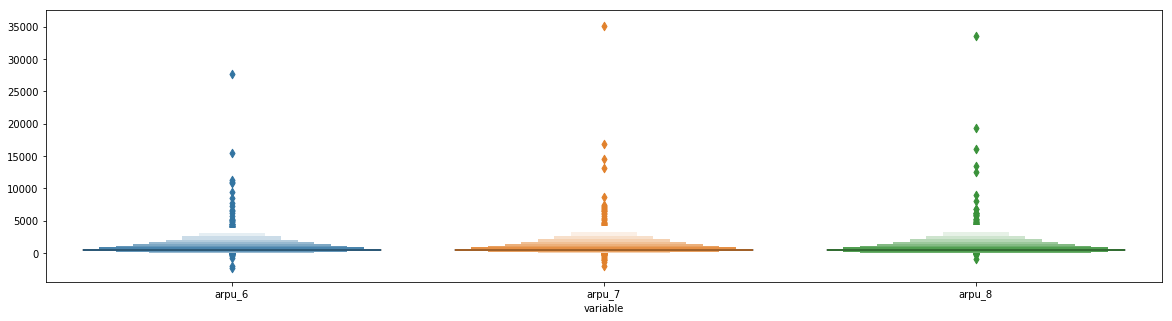

,arpu_6,arpu_7,arpu_8
count,29091.000000,29091.000000,29091.000000
mean,589.609339,597.301703,544.964305
std,438.829214,465.542918,495.056403
min,-2258.709000,-2014.045000,-945.808000
25%,367.359000,371.354000,299.635500
50%,498.988000,500.197000,460.151000
75%,705.890500,708.124500,680.901500
max,27731.088000,35145.834000,33543.624000


In [31]:
# analyse the remaining columns 
def display_univariate(term):
    printmd(f"### Comparing columns related to {term}")
    _cols=[i for i in DS_HH.columns if term in i]
    
    _temp=pd.melt(DS_HH,value_vars =_cols)
    plt.figure(figsize=(20,5))
    sns.boxenplot(y="value",x="variable",data=_temp,scale="linear")  
    plt.ylabel("")    
    plt.show()
    display(DS_HH[_cols].describe())
    
display_univariate("arpu")

# Review comments 

- Intuitively ARPU, i.e., average revenue per user, should be +ve value but in some cases we could see -ve results;
- Similalrly, monthly ARPU for some customers is very high in the range of 27k to 33k, which needs to be further probed or taken out from our dataset. We do not know if these customers are wrongly categorized corporte customers or resellers; 
- High usage is justifibale in case of postpaid customers, but in case of prepaid customer ARPU of more than 20k seems suspicious and these could be possibly recharge sellers <font color="red"> these are could be recharge sellers </font>;
- As a result, we are taking a call for deleting the following customers: 

    - customers whose ARPU is less than 0, as it indicates corrupt data; 
    - customers having high ARPU of over 5k, on the assumption that these are resellers

In [32]:
# observe -ve ARPU 

_temp=DS_HH[DS_HH.arpu_6<0 | (DS_HH.arpu_7<0) | (DS_HH.arpu_8<0)]

printmd(f"### Number of Rows having -ve ARPU {len(_temp)}")

#delete numbers having-ve ARPU
DS_HH=DS_HH.drop(_temp.index,axis=0)


_temp = DS_HH[np.logical_or(np.logical_or(DS_HH.arpu_6>5000,DS_HH.arpu_7>=5000),DS_HH.arpu_8>=5000)]

printmd(f"### High ARPU could be resellers {len(_temp)}")

#delete numbers having high ARPU
DS_HH=DS_HH.drop(_temp.index,axis=0)

### Number of Rows having -ve ARPU 34

### High ARPU could be resellers 31

### Comparing columns related to onnet

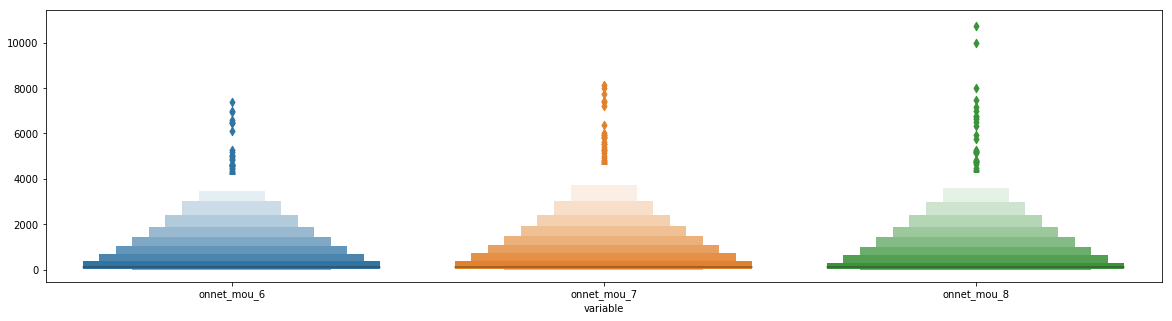

,onnet_mou_6,onnet_mou_7,onnet_mou_8
count,29026.000000,29026.000000,29026.000000
mean,300.425337,310.242618,273.137232
std,463.366182,486.103618,470.514185
min,0.000000,0.000000,0.000000
25%,42.480000,43.045000,29.332500
50%,128.535000,129.580000,103.710000
75%,360.262500,370.027500,305.487500
max,7376.710000,8157.780000,10752.560000


In [33]:
# Review of net MOU (Minutes of Usage)

display_univariate("onnet")

# Review comments 

- There are no negative values, meaning data is not corrupt;
- A large proportion of data is scattered around zero and going up in pyramidical structure which is prefectly fair; 
- There are some outliers in the dataset (4th quartile), who are actually the top revenue contributors for the company and this is where we would like to focus in terms of customer retention. 

### Comparing columns related to offnet

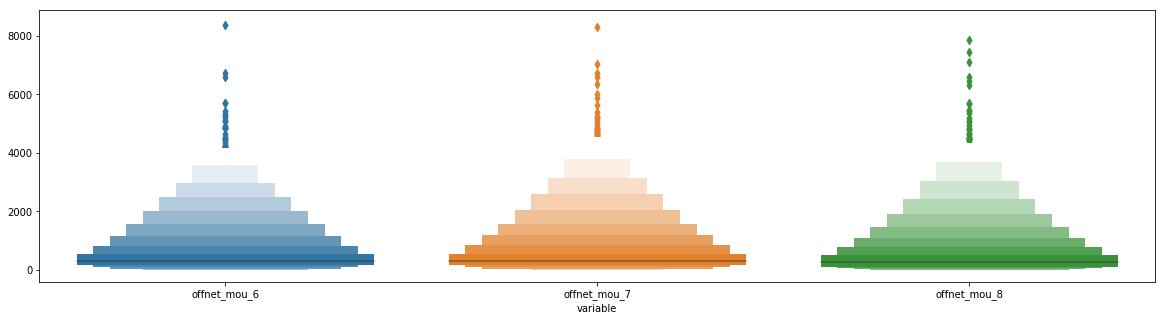

,offnet_mou_6,offnet_mou_7,offnet_mou_8
count,29026.00000,29026.000000,29026.000000
mean,421.12241,430.148877,381.261926
std,467.59935,484.405937,464.147708
min,0.00000,0.000000,0.000000
25%,140.39000,140.695000,101.690000
50%,285.91000,288.400000,247.915000
75%,527.95500,542.330000,491.537500
max,8362.36000,8316.360000,7857.780000


In [34]:
display_univariate("offnet")

### Review comments 

Median value for offnet calls comes to be around 250 minutes; data in the last quartile peaks and creates outliers. These values again indicate high value customers. We do not see much difference between MOU and Offnet MOU in the 4th quartile, meaning these customers have friends and colleagues mostly on different network. This data may be useful for company in rolling out promotional schemes for onboarding other operator customers.

### Comparing columns related to roam

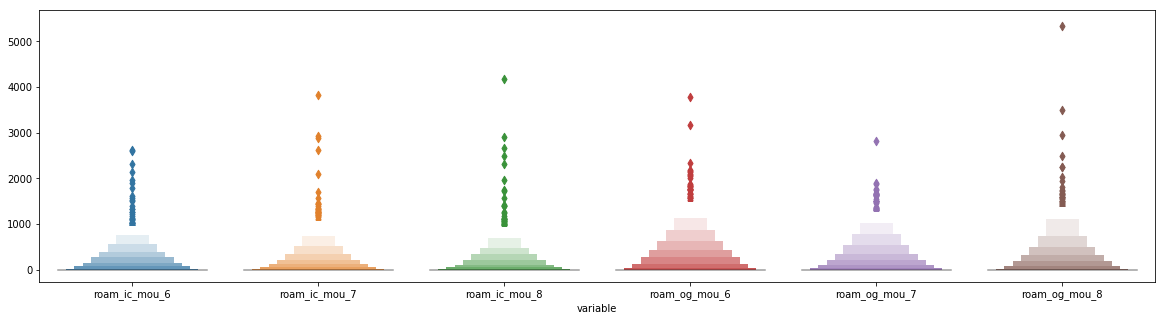

,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8
count,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000
mean,17.470754,13.746004,13.519087,29.512574,22.484054,21.900449
std,78.971018,77.105643,75.232403,119.056311,99.033769,106.304515
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2613.310000,3813.290000,4169.810000,3775.110000,2812.040000,5337.040000


In [35]:
display_univariate("roam")

### Review comments 

- Maximum customers are using the network for local usages only; 
- Few customers, as can be seen from the max value, are using roaming services with the maximum MOU of around 2.6k to 5.3k, incoming and outgoing included;
- While, there is no distinc pattern between incoming and outgoing calls, we can notice that OG is in general hugher than IC. 

### Comparing columns related to loc_og

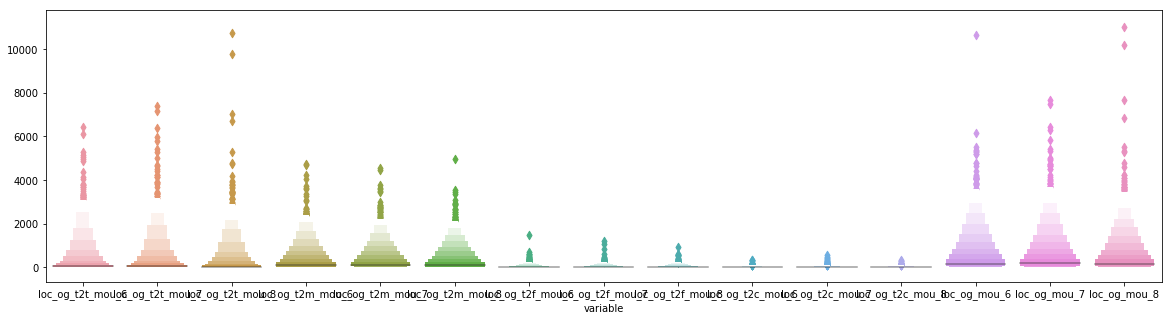

,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8
count,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000
mean,95.930668,97.574611,88.858273,183.159511,184.203341,170.914367,7.070638,7.227605,6.636098,1.581071,1.878024,1.735475,286.169687,289.014609,266.417285
std,239.014744,251.481549,237.350931,251.028433,242.118148,235.545433,22.930561,22.894780,20.502055,6.963111,9.345567,7.420982,382.136723,378.918085,368.621086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.680000,9.582500,6.342500,31.360000,35.210000,24.560000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.790000,59.532500,41.280000
50%,33.230000,34.130000,29.710000,103.380000,106.690000,93.260000,0.360000,0.450000,0.250000,0.000000,0.000000,0.000000,169.270000,175.120000,153.535000
75%,92.705000,93.275000,86.630000,242.437500,243.437500,227.887500,5.197500,5.410000,4.840000,0.000000,0.110000,0.080000,377.375000,382.275000,354.425000
max,6431.330000,7400.660000,10752.560000,4729.740000,4557.140000,4961.330000,1466.030000,1196.430000,928.490000,342.860000,569.710000,351.830000,10643.380000,7674.780000,11039.910000


In [36]:
display_univariate("loc_og")

#### Review comments 

- Interestingly, mobile to fixed line calls very low indicating deeper penetration of mobile phones; 
- Calls to contact center, as % of total T2T calls, is very low.  Either, the customer service is very prompt in handling customer complaints or complaints are being closed arbitrarily. This information can be shared with Telecom Management;
- Other data is not exhibiting any out of bound property.

### Comparing columns related to total_og

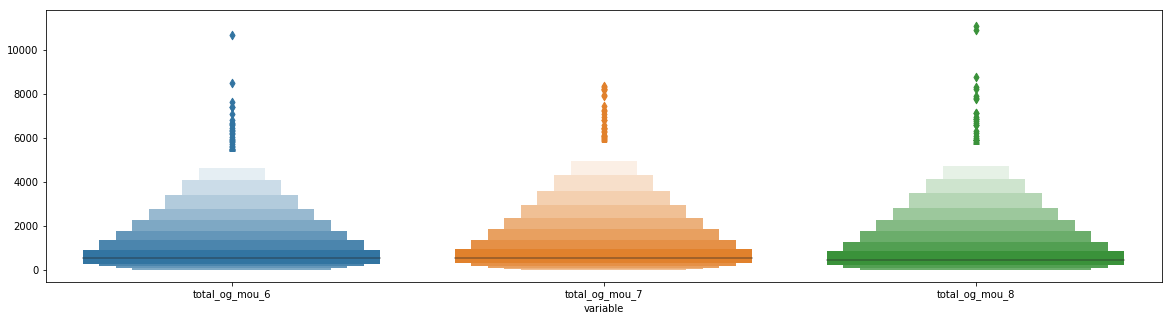

,total_og_mou_6,total_og_mou_7,total_og_mou_8
count,29026.000000,29026.000000,29026.000000
mean,693.998156,720.721408,635.087517
std,657.577168,683.247906,676.823151
min,0.000000,0.000000,0.000000
25%,273.400000,284.630000,200.487500
50%,518.870000,537.440000,448.690000
75%,907.362500,945.295000,847.307500
max,10674.030000,8327.880000,11046.740000


In [37]:
display_univariate("total_og")

#### Review comments 

- Median customer (50%) are using around 500 MOU of outgoing calls. While the data in last quartile has extreme outliers, there is not much variation between mean and median value. This indicates huge volume in low end customers and may indicate significant chunk of low value but high volume customer segment;
- Last quartile indicate high MOU and reflect high end customers, who are our target variable.

### Comparing columns related to loc_ic

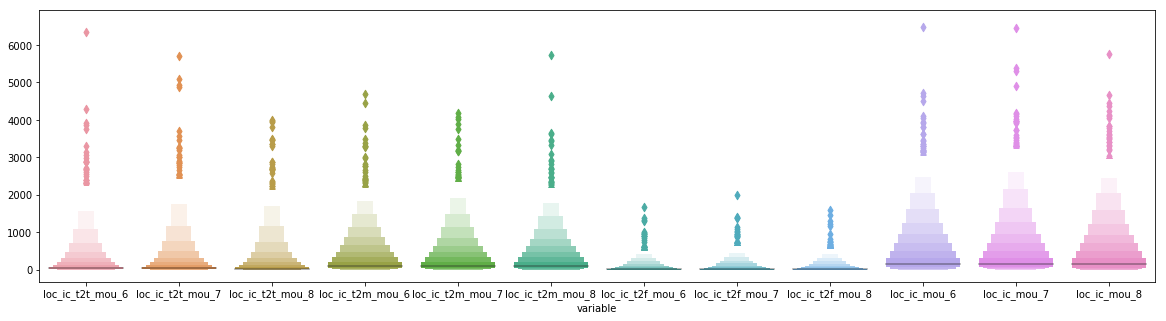

,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8
count,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000
mean,69.185748,71.258547,67.115697,160.825599,163.081930,156.309719,15.695503,16.706172,14.969482,245.716756,251.056734,238.404613
std,157.847961,168.846069,157.459663,220.571209,219.505828,216.637242,45.898128,49.728825,44.105073,310.336241,316.217906,307.679687
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.660000,9.930000,7.340000,34.395000,39.632500,31.730000,0.000000,0.000000,0.000000,58.687500,65.740000,53.532500
50%,29.590000,30.990000,27.680000,95.235000,98.610000,92.220000,2.030000,2.330000,1.990000,153.185000,157.435000,146.550000
75%,74.605000,75.625000,71.802500,204.547500,206.475000,200.000000,12.610000,13.290000,11.990000,317.675000,320.902500,306.990000
max,6351.440000,5709.590000,4003.210000,4693.860000,4171.510000,5738.460000,1678.410000,1983.010000,1588.530000,6496.110000,6466.740000,5748.810000


In [38]:
display_univariate("loc_ic")

### Comparing columns related to total_rech_num

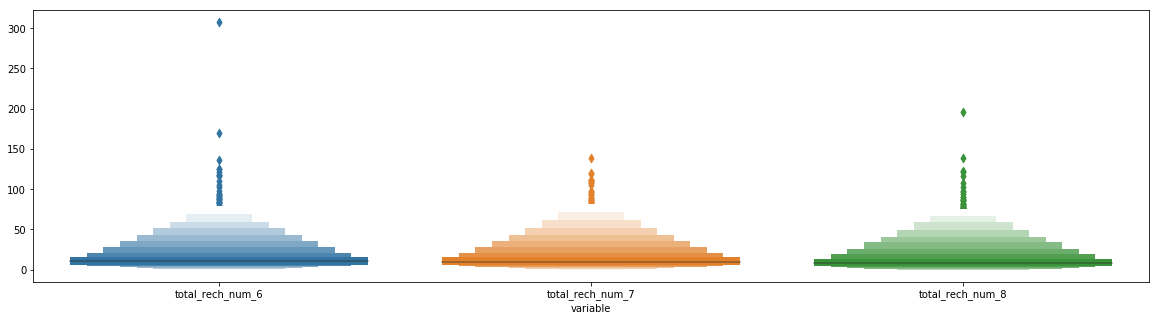

,total_rech_num_6,total_rech_num_7,total_rech_num_8
count,29026.000000,29026.000000,29026.000000
mean,12.180803,12.033591,10.363639
std,9.543530,9.636173,9.472162
min,0.000000,0.000000,0.000000
25%,6.000000,6.000000,4.000000
50%,10.000000,9.000000,8.000000
75%,15.000000,15.000000,13.000000
max,307.000000,138.000000,196.000000


In [39]:
display_univariate("total_rech_num")

### Review comments 

- On an average, customer are recharging around 9.5 times in a month. While the data in last quartile has extreme outliers vis-a-vis 75 %ile data, there is not much variation between mean and median value. This indicates huge volume in low end customers and may indicate significant chunk of low value but high volume customer segment;
- Some customers are recharging over 138+ times, which seems abnormal and may still indicate presence of resllers in our dataset. However, as of now, we will not take any action on this.

### Comparing columns related to total_rech_amt

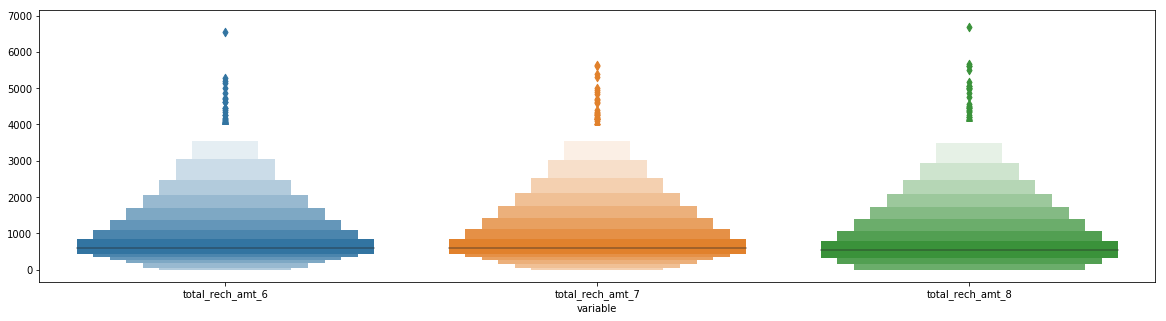

,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8
count,29026.000000,29026.000000,29026.000000
mean,693.329257,698.401364,617.050575
std,436.462531,446.797601,481.148670
min,0.000000,0.000000,0.000000
25%,437.000000,435.000000,322.000000
50%,586.000000,590.000000,529.000000
75%,839.000000,842.000000,798.750000
max,6549.000000,5630.000000,6698.000000


In [40]:
display_univariate("total_rech_amt")

### Review comments 

- Median recharge amount is around 500ish and mean recharge amount is 600ish;
- While the data in last quartile has extreme outliers vis-a-vis 75 %ile data, there is not much variation between mean and median value. This indicates huge volume in low end customers and may indicate significant chunk of low value but high volume customer segment;
- Last quartile indicate high end customers, who are our target variable.

### Comparing columns related to max_rech

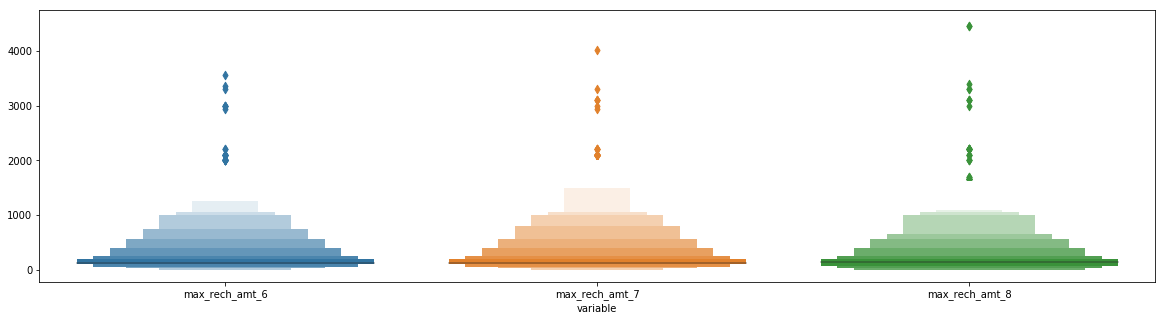

,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8
count,29026.000000,29026.000000,29026.000000
mean,169.487873,175.510818,163.657617
std,165.927052,175.182084,164.937841
min,0.000000,0.000000,0.000000
25%,110.000000,110.000000,68.000000
50%,120.000000,128.000000,130.000000
75%,200.000000,200.000000,198.000000
max,3559.000000,4010.000000,4449.000000


In [41]:
display_univariate("max_rech")

### Review comments 

- Median recharge anount is aorund 120 and mean recharge amount is aorund 168;
- While the data in last quartile has extreme outliers vis-a-vis 75 %ile data, there is not much variation between mean and median value. This indicates huge volume in low end customers and may indicate significant chunk of low value but high volume customer segment;
- Last quartile indicate high end customers, who are our target variable.


### Comparing columns related to vol_

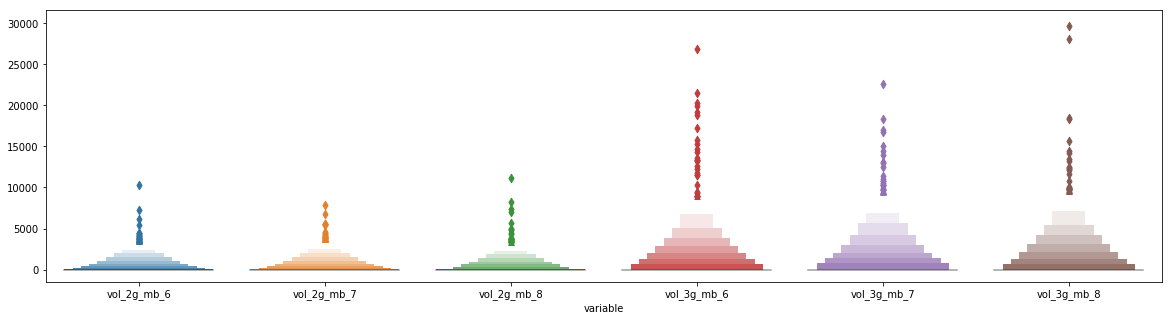

,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8
count,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000
mean,78.963028,78.549136,69.946220,252.991410,275.531253,269.351146
std,277.219480,280.007467,269.702368,814.262361,822.889885,838.077712
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14.690000,15.787500,10.445000,0.000000,3.487500,0.000000
max,10285.900000,7873.550000,11117.610000,26826.130000,22613.100000,29651.830000


In [42]:
display_univariate("vol_")

### Review comments 

- A significant proportion of customers are using 2G in place of 3G data. High end customers in 4th quartile are using most of the data;
- A large number of customers are using zero data, meaning they are mostly voice calls oriented customers.

### Comparing columns related to vbc

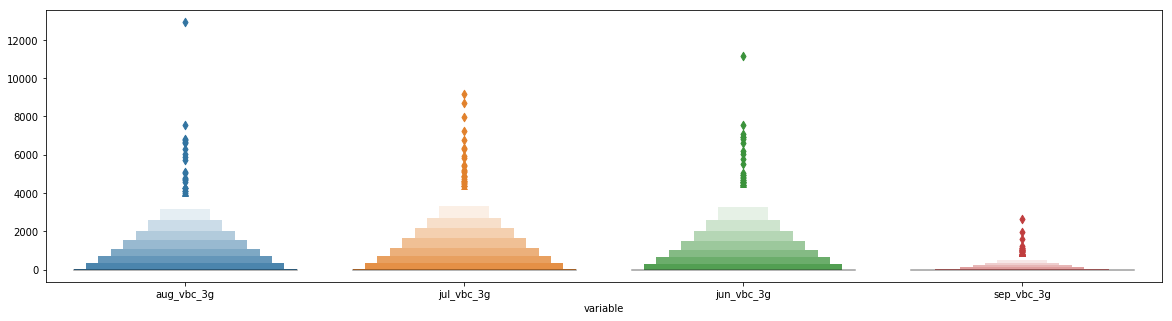

,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
count,29026.000000,29026.000000,29026.000000,29026.000000
mean,131.266179,136.459260,121.554558,6.641614
std,393.301995,410.314137,389.363359,48.422487
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,3.917500,2.790000,0.000000,0.000000
max,12916.220000,9165.600000,11166.210000,2618.570000


In [43]:
display_univariate("vbc")

### Review comment 

- Very few customers are using data service on Pay as you go basis. Howeevr, those who are using this service are paying large amount high tariff for this service;
- We have also noticed September column here, which we forget to delete. Hence, deleting the same.

In [44]:
## Deleting sep_vbc_3g 

DS_HH=DS_HH.drop("sep_vbc_3g",axis=1)

### Comparing columns related to sachet

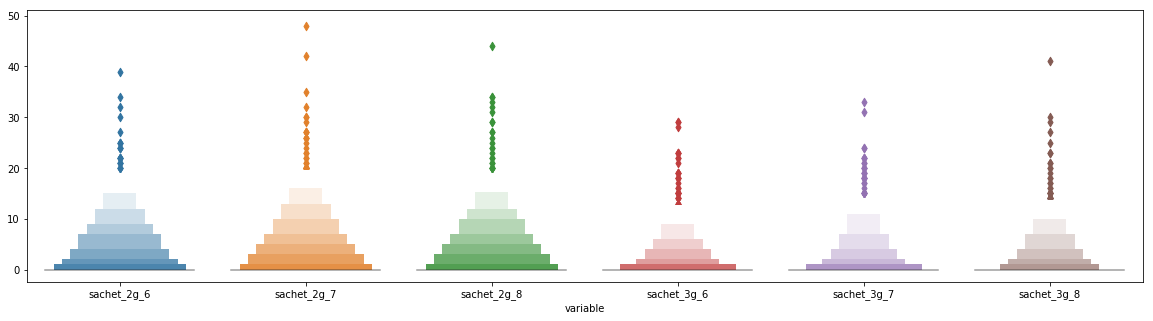

,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8
count,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000
mean,0.502102,0.591745,0.614518,0.139599,0.150796,0.141735
std,1.703382,1.908304,1.853273,0.879792,0.958950,0.958877
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,39.000000,48.000000,44.000000,29.000000,33.000000,41.000000


In [45]:
display_univariate("sachet")

### Comparing columns related to monthly_

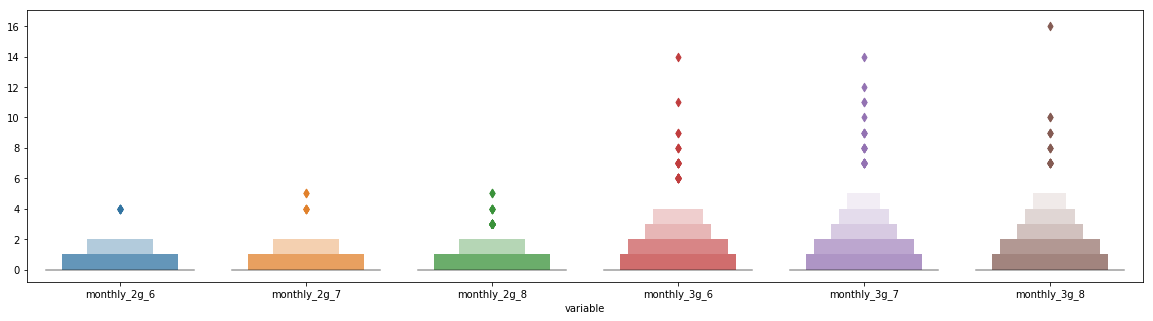

,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8
count,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000,29026.000000
mean,0.125956,0.132915,0.115620,0.170640,0.184559,0.173741
std,0.375820,0.389934,0.359537,0.566897,0.616241,0.583990
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,5.000000,5.000000,14.000000,14.000000,16.000000


In [46]:
display_univariate("monthly_")

### Review comments 

- Most of the subscribers are opting for high speed 3G plan insted of 2G plan


### Bivariate Analysis

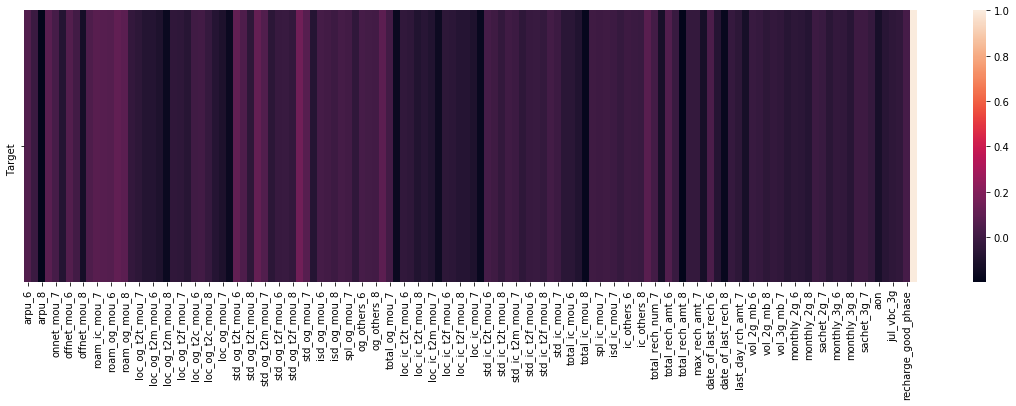

In [47]:
# Correlation graph with target variable

_corr=DS_HH.corr()

plt.figure(figsize=(20,5))
sns.heatmap(_corr[_corr.index =="Target"])

plt.show()

### Review comments

- No visible strong corrlation noticed between dependent variable and independent variable

### Comparing with arpu vs Target variable

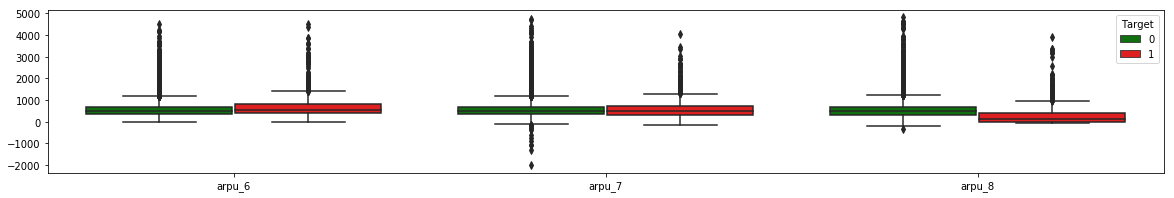

In [48]:
def bivariate_analysis(token):
    printmd(f"### Comparing with {token} vs Target variable")
    _cols=[i for i in DS_HH.columns if token in i]
    _col1 = list(_cols)
    _cols.append("Target")
    
    plt.figure(figsize=(20,3))
    _temp=pd.melt(DS_HH,id_vars=["Target"],value_vars=_col1)
    sns.boxplot(y="value", x="variable",
            hue="Target", palette=["g", "r"],data=_temp)
    plt.xlabel("")
    plt.ylabel("")
    plt.show()
    
bivariate_analysis("arpu")

### Review remaks 

- The graph indicates that ARPU is steadily declining for churn customers and goes substantially below than normal customers in the 8th month. Whereas, for other customers ARPU is relatively stable

### Comparing with aon vs Target variable

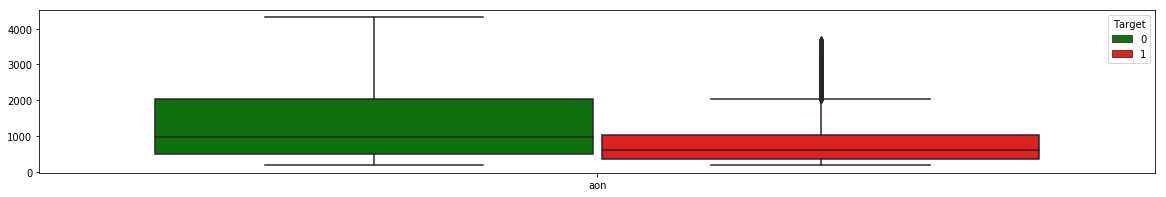

In [49]:
bivariate_analysis("aon")

### Review Remaks 

- The above graph is a very good indication that customers whose age on netwrok (AON) is less, they have a high probability of churning

### Comparing with onnet_ vs Target variable

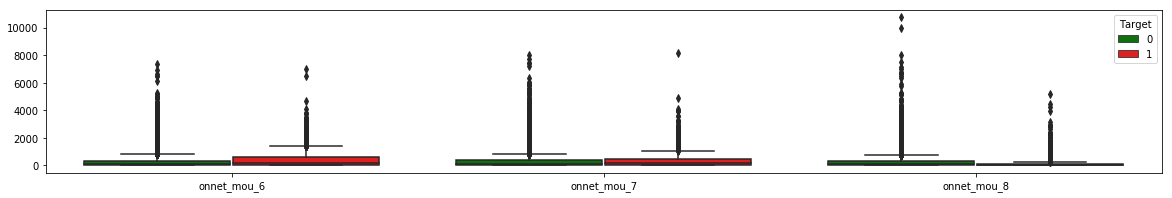

### Comparing with offnet vs Target variable

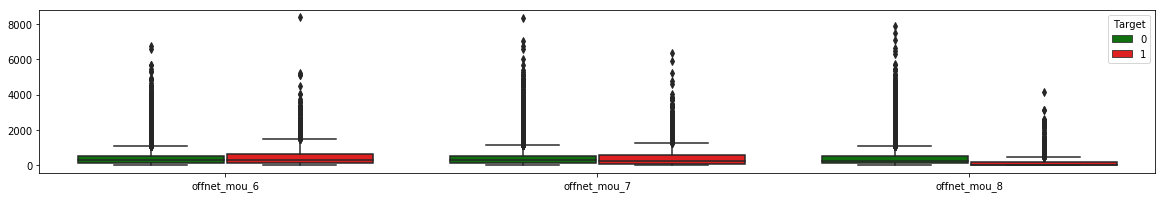

### Comparing with total_og_ vs Target variable

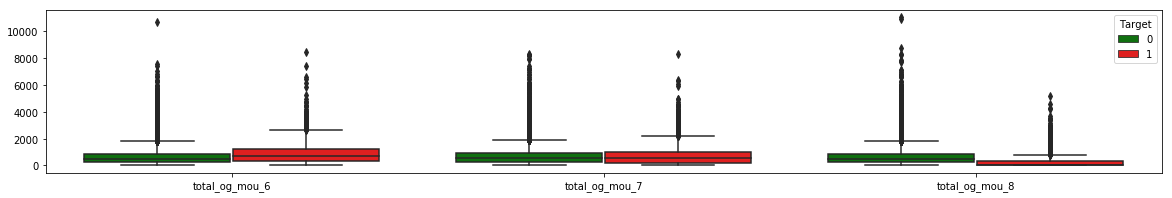

### Comparing with vol_ vs Target variable

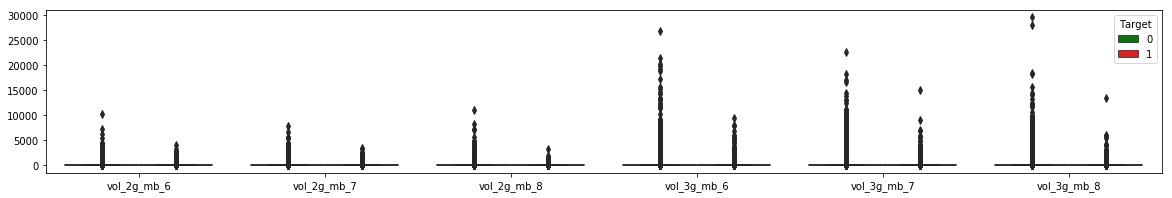

### Comparing with total_rech_amt vs Target variable

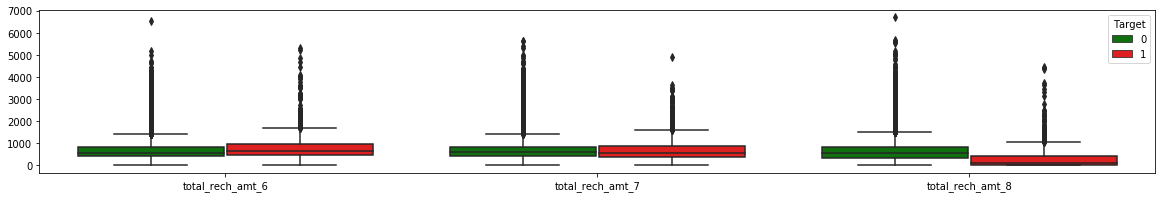

### Comparing with total_rech_num vs Target variable

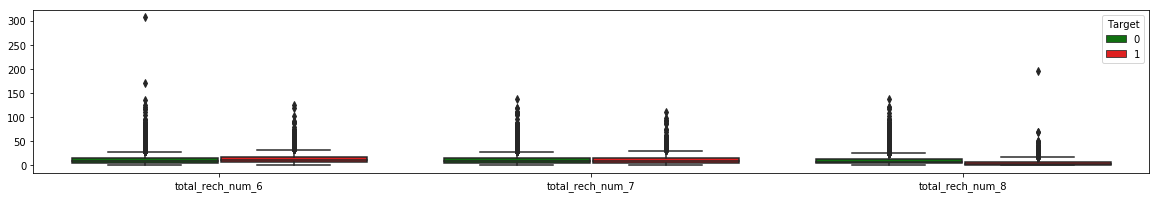

### Comparing with vbc vs Target variable

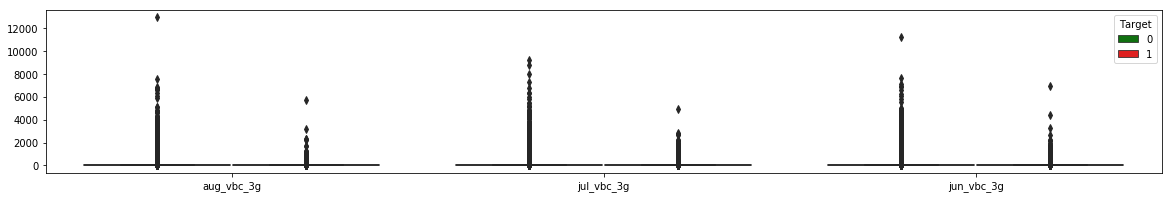

In [50]:
bivariate_analysis("onnet_")
bivariate_analysis("offnet")

bivariate_analysis("total_og_")

bivariate_analysis("vol_")

bivariate_analysis("total_rech_amt")

bivariate_analysis("total_rech_num")

bivariate_analysis("vbc")

### Review comments 

- There is a distinct similarity in all the graphs given above. While, churn customers data is comparable or better than normal customers in the 6th month, it steadily declines through 7th month to 8th month;
- Thus, 8th month is a good example of 'action phase', where the dissatisfaction with existing netwrok is growing or customer is being poached away by competitors. However, the latter seems unlikely as poached customers usage will fall sharply rather the declining gradually.

In [51]:
# Creation of new derived fields by analysing change in customer behaiour on month of AUG-2019 from the average units consumptions for JUN and JUL. 

DS_HH=DS_HH.drop("spl_ic_mou_6",axis=1)
_list = [i for i in DS_HH.columns if "_6" in i]

for i in _list:
    j = i.replace("_6","_7")
    k = i.replace("_6","_8")
    _new= i.replace("_6","diff")
    _new1= i.replace("_6","diffvalue")
    _avg = DS_HH[[i,j]].mean(axis=1)
   
    
    
    DS_HH[_new]=(_avg-DS_HH[k])/_avg
    #DS_HH[_new1]=(_avg-DS_HH[k])
   # DS_HH[_month1]=( DS_HH[j] -DS_HH[k])/DS_HH[j] 
    
    

pd.options.mode.use_inf_as_na = True
DS_HH = DS_HH.fillna(0)

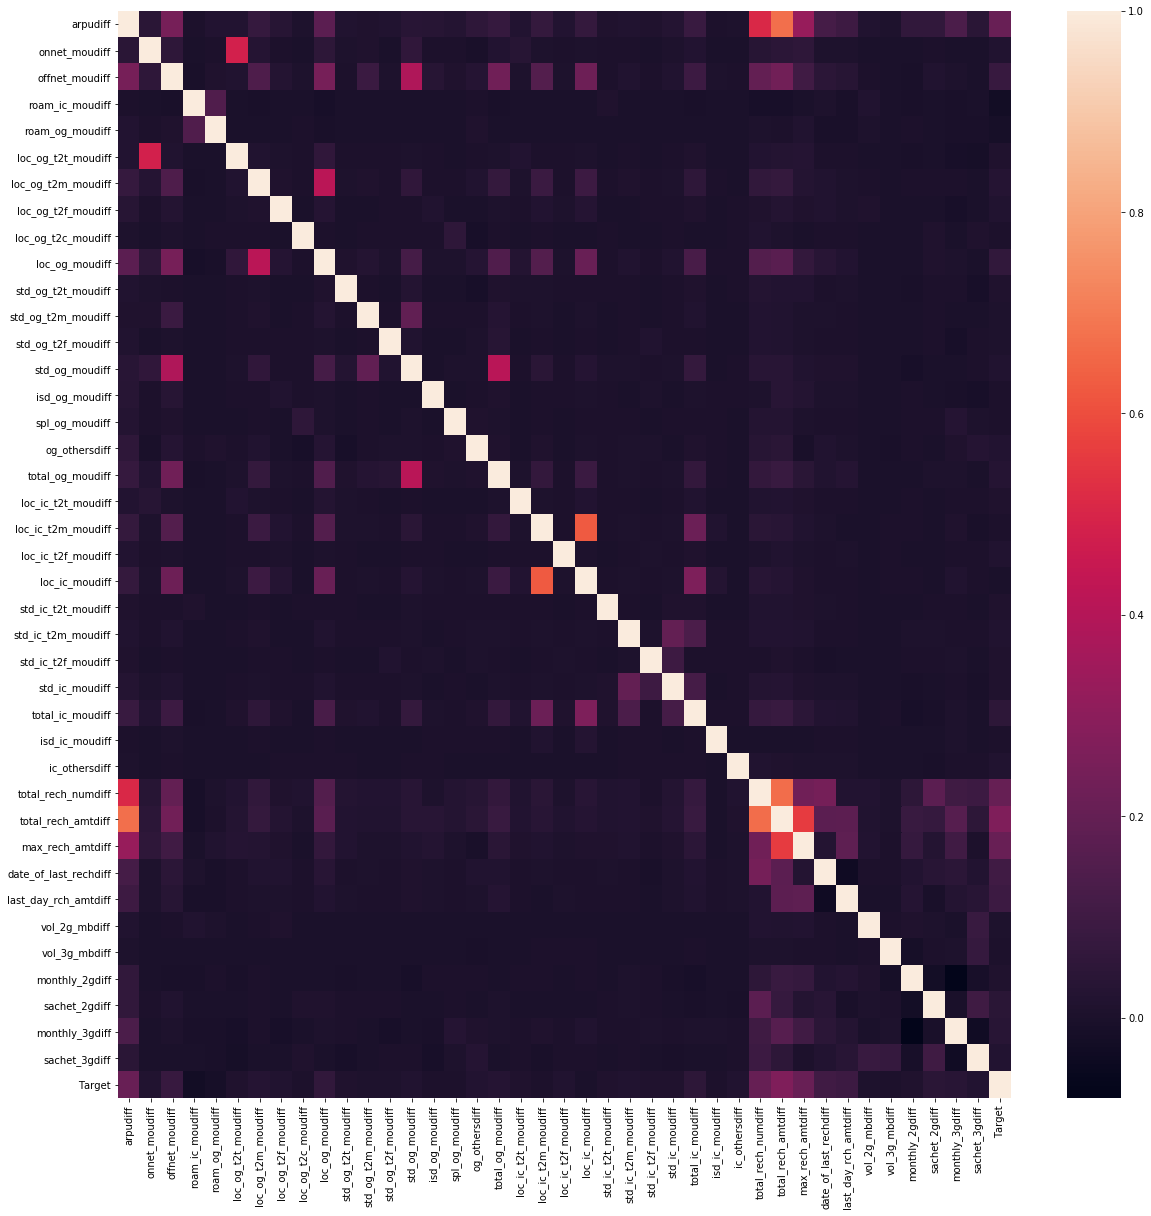

arpudiff              0.208540
total_rech_numdiff    0.206034
total_rech_amtdiff    0.268740
max_rech_amtdiff      0.210266
Target                1.000000
Name: Target, dtype: float64

In [52]:
# Target Variable correlation for newly derived fields

_list1 = [i for i in DS_HH.columns if "diff" in i]

_list1.append("Target")
plt.figure(figsize=(20,20))
sns.heatmap(DS_HH[_list1].corr())
plt.show()
_temp=DS_HH[_list1].corr()["Target"].abs()

_temp[_temp >0.2]

## Review Comments 

- There is no significant correlation witnessed between the derived metrics and the target variable. However, some low level of corrleation can be seen between total recharge amount, maximum recharge amount and ARPU difference with the target variable.

We can further profile the customer based on preferable Voice and Data usages

In [53]:
# understand customer nature 

# Tag the customer if customer consuming data or not
DS_HH["is_data_customer"] =  DS_HH[["vol_2g_mb_6","vol_2g_mb_7","vol_2g_mb_8","vol_3g_mb_6","vol_3g_mb_7","vol_3g_mb_8"]].sum(axis=1) >1

# Tag the customer if customer consuming voice calls or not
_10th_percentile=np.percentile(DS_HH[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1),10)
DS_HH["Call_oriented"] =  DS_HH[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1) >_10th_percentile

Derived field to understand customer using data service or not

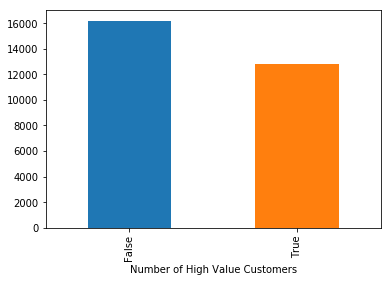

Derived field to understand customer is using call on priority or not

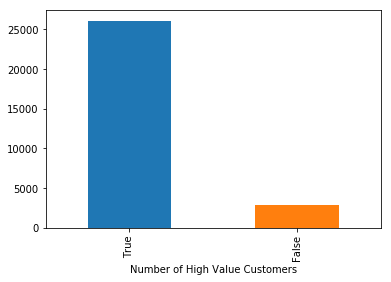

In [56]:
#arpudiff, Call_oriented, Target 

printmd("Derived field to understand customer using data service or not")
DS_HH.is_data_customer.value_counts().plot(kind="bar")
plt.xlabel("customer using Data")
plt.xlabel("Number of High Value Customers")
plt.show()


printmd("Derived field to understand customer is using call on priority or not")
DS_HH.Call_oriented.value_counts().plot(kind="bar")
plt.xlabel("customer using voice")
plt.xlabel("Number of High Value Customers")
plt.show()

### Feature scaling and Model readiness

- Outlier treatment
- Train and test data split 
- Feature sclaing on training data set

In [57]:
# Outlier treatrment by adjusting bounderies for all numeric fields with the ranges of 0.01 and 0.095

DS_HH_copy= DS_HH.copy()


# Cration of Dummy variables 
var_numarical_fields = DS_HH_copy.drop("Target",axis=1).columns 

#treating outliers
def reset_bounderies(column_name):
    _temp_percet = DS_HH_copy[column_name].quantile([0.01,0.99]).values
    DS_HH_copy[column_name]=DS_HH_copy[column_name].apply(lambda x:  _temp_percet[0] if x < _temp_percet[0] else x )
    DS_HH_copy[column_name]=DS_HH_copy[column_name].apply(lambda x:  _temp_percet[1] if x > _temp_percet[1] else x )
    

# apply boundery treatment for each columns
for i in var_numarical_fields:
    reset_bounderies(i)


printmd(f"### High Value Data set shape {DS_HH_copy.shape}")

#split data into train and test
train,test = train_test_split(DS_HH_copy,test_size=0.3, random_state=42)

printmd(f"### Train Data set shape {train.shape}")
printmd(f"### Test Data set shape {test.shape}")

X_train = train.copy()
X_train = X_train.drop("Target",axis=1)
y_train = train[["Target"]]

X_test= test.copy()
X_test = X_test.drop("Target",axis=1)
y_test = test[["Target"]]

printmd(f"### X_Train Data set shape {X_train.shape}")
printmd(f"### y_train Data set shape {y_train.shape}")

printmd(f"### Churn Rate in training data <font color='red'> <b> { round(train[train.Target ==1].shape[0] / train.shape[0],2) } </b> </font>")

printmd(f"### Churn Rate in test data <font color='red'> <b>{ round(test[test.Target ==1].shape[0] / test.shape[0],2) } </b> </font>")


printmd("### Sclaed Data Set")
StandardSC = StandardScaler()
_cols = list(X_train.columns)
X_train = pd.DataFrame(StandardSC.fit_transform(X_train))
X_train.columns = _cols
display(X_train.head())

X_test = pd.DataFrame(StandardSC.transform(X_test))
X_test.columns = _cols

### High Value Data set shape (29026, 169)

### Train Data set shape (20318, 169)

### Test Data set shape (8708, 169)

### X_Train Data set shape (20318, 168)

### y_train Data set shape (20318, 1)

### Churn Rate in training data <font color='red'> <b> 0.08 </b> </font>

### Churn Rate in test data <font color='red'> <b>0.08 </b> </font>

### Sclaed Data Set

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_7,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,recharge_good_phase,arpudiff,onnet_moudiff,offnet_moudiff,roam_ic_moudiff,roam_og_moudiff,loc_og_t2t_moudiff,loc_og_t2m_moudiff,loc_og_t2f_moudiff,loc_og_t2c_moudiff,loc_og_moudiff,std_og_t2t_moudiff,std_og_t2m_moudiff,std_og_t2f_moudiff,std_og_moudiff,isd_og_moudiff,spl_og_moudiff,og_othersdiff,total_og_moudiff,loc_ic_t2t_moudiff,loc_ic_t2m_moudiff,loc_ic_t2f_moudiff,loc_ic_moudiff,std_ic_t2t_moudiff,std_ic_t2m_moudiff,std_ic_t2f_moudiff,std_ic_moudiff,total_ic_moudiff,isd_ic_moudiff,ic_othersdiff,total_rech_numdiff,total_rech_amtdiff,max_rech_amtdiff,date_of_last_rechdiff,last_day_rch_amtdiff,vol_2g_mbdiff,vol_3g_mbdiff,monthly_2gdiff,sachet_2gdiff,monthly_3gdiff,sachet_3gdiff,is_data_customer,Call_oriented
0,0.152237,-0.468523,-0.652264,2.172315,0.975843,0.361561,-0.648157,-0.697030,-0.863124,-0.289151,-0.261389,-0.264387,-0.307318,-0.281752,-0.280824,-0.397277,-0.226207,-0.526277,-0.673851,-0.507667,-0.744288,-0.429987,-0.436378,-0.424886,5.966171,1.250542,-0.041064,-0.673421,-0.484933,-0.775789,2.684178,1.239742,0.665872,-0.400426,-0.461276,-0.491107,-0.249689,-0.244009,-0.244323,1.473114,0.489952,0.115403,-0.165906,-0.168236,-0.15582,4.716412,1.745142,-0.096917,0.183950,0.0,0.0,1.062689,0.227754,-0.311544,0.010830,-0.480225,-0.551427,-0.567839,-0.682760,-0.803408,-0.418498,-0.455136,-0.455797,-0.455090,-0.716016,-0.817042,1.118542,-0.271804,-0.354879,0.642933,-0.171115,-0.375284,-0.283334,-0.282746,-0.28299,0.771517,-0.268420,-0.429089,-0.221959,-0.737169,-0.860274,-0.200083,-0.260230,-0.272136,-0.259400,-0.259806,-0.265198,-0.260275,-0.243059,-0.669684,-0.259209,0.215022,-0.850176,-0.592421,-0.267544,-0.289984,-0.429866,0.768163,-2.132991,0.603946,0.284261,0.244606,-0.201544,-0.345086,-0.337383,-0.322678,-0.384121,-0.396846,-0.386922,-0.340242,-0.350048,-0.327436,-0.335834,-0.353045,-0.374423,-0.323655,-0.330341,-0.322102,-0.237514,-0.235677,-0.220909,-0.838860,-0.379936,-0.376235,-0.359719,-0.385115,0.776359,0.598368,1.114615,0.035158,-0.001153,0.703743,0.830242,0.123535,0.468520,0.979645,0.396727,0.519251,-0.015104,0.424168,-0.181929,0.333325,1.823296,0.833366,0.686670,0.973040,0.516040,1.104563,0.370788,0.409490,0.070799,0.479569,1.22582

#### PCA 

- Dimentionality reduction through PCA

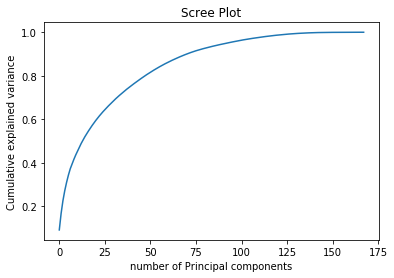

### Number of PC's explaining variation of 90% on the test data set is <font color='red'> 70 PC's </font>

In [58]:
pca = PCA()
np.random.RandomState(1999)

pca.fit(X_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of Principal components')
plt.ylabel('Cumulative explained variance')
plt.savefig('pca_no')
plt.title("Scree Plot")
plt.show()

_no=len([i for i in list(np.cumsum(pca.explained_variance_ratio_)) if i <=0.90])

printmd(f"### Number of PC's explaining variation of 90% on the test data set is <font color='red'> {_no} PC's </font>")

### Review comments 

- Analyzing the above scree plot, we come to the conclusion that most of the variance is explained by 70 predictor variables and as such we will proceed with 70 fields 

In [59]:
pca = IncrementalPCA(n_components= 70, batch_size =100)

X_train_PCA = pd.DataFrame(pca.fit_transform(X_train))
X_test_PCA = pd.DataFrame(pca.transform(X_test))

# Model building with imbalanced data set

First we will try with plain vanilla Logistic Regression model and then compare the results with various ensemble models, such as decision tree based models and also by using boosting techniques

## Logistic regression

In [60]:
# Working with logistic regression

models1 = {
    'Logistic_regression': LogisticRegression()    
}

params1 = {
    'Logistic_regression': {'C': [1,5,10] }   
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(X_train, y_train,scoring="recall", n_jobs=2)

helper1.score_summary()

Running GridSearchCV for Logistic_regression.
Fitting 5 folds for each of 3 candidates, totalling 15 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Logistic_regression


[Parallel(n_jobs=2)]: Done  15 out of  15 | elapsed:   46.6s finished


,estimator,min_score,mean_score,max_score,std_score,C
2,Logistic_regression,0.289389,0.314235,0.324759,0.0130607,10
1,Logistic_regression,0.289389,0.313592,0.322581,0.0125976,5
0,Logistic_regression,0.289389,0.309738,0.329032,0.0132764,1


### Summary Logistic Regression 

- week regulization of C with the highest values indicating best recall score. 
- Will Review with the probability prediction to manage best metric to manage both accuracy and recall scores


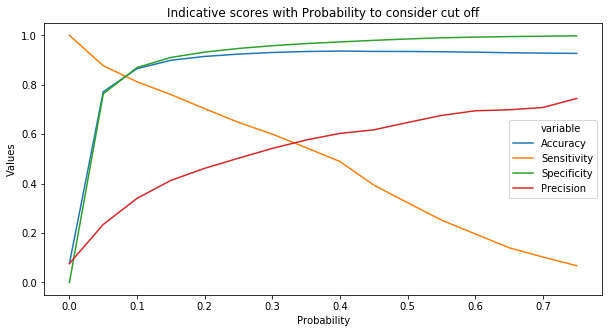

,Prob,Accuracy,Sensitivity,Specificity,Precision,TP,FN,TN,FP
0,0.00,0.076435,1.000000,0.000000,0.076435,1553.0,0.0,0.0,18765.0
1,0.05,0.771926,0.877012,0.763229,0.234625,1362.0,191.0,14322.0,4443.0
2,0.10,0.865390,0.811977,0.869811,0.340443,1261.0,292.0,16322.0,2443.0
3,0.15,0.899104,0.760464,0.910578,0.413081,1181.0,372.0,17087.0,1678.0
4,0.20,0.914706,0.703155,0.932214,0.461929,1092.0,461.0,17493.0,1272.0
5,0.25,0.924107,0.647778,0.946976,0.502749,1006.0,547.0,17770.0,995.0
6,0.30,0.930751,0.600129,0.958114,0.542491,932.0,621.0,17979.0,786.0
7,0.35,0.934639,0.545396,0.966853,0.576583,847.0,706.0,18143.0,622.0
8,0.40,0.936362,0.489375,0.973355,0.603175,760.0,793.0,18265.0,500.0
9,0.45,0.935033,0.394076,0.979803,0.617558,612.0,941.0,18386.0,379.0


## Importent fields

,0,coef,abs_coef
59,loc_ic_t2m_mou_8,-1.036921,1.036921
41,std_og_mou_8,0.999460,0.999460
99,date_of_last_rech_8,-0.996006,0.996006
158,date_of_last_rechdiff,-0.661480,0.661480
7,offnet_mou_7,0.572364,0.572364
8,offnet_mou_8,-0.569293,0.569293
19,loc_og_t2m_mou_7,-0.562031,0.562031
34,std_og_t2m_mou_7,-0.540439,0.540439
40,std_og_mou_7,0.513292,0.513292
31,std_og_t2t_mou_7,-0.510587,0.510587


In [61]:
# Logistic regression to find best probability score
lm = LogisticRegression(C=1)
fit1 = lm.fit(X_train,y_train)
y_pred_prob = fit1.predict_proba(X_train)

measures = pd.DataFrame(columns=["Prob","Accuracy","Sensitivity","Specificity","Precision","TP","FN","TN","FP"])
#measures["cutof"] =np.arange(0,1,0.05)
for i in np.arange(0,0.8,0.05):
    _altered_y = [1 if j >=i else 0 for j in y_pred_prob[:,1]]
    mat = confusion_matrix(y_train,_altered_y)
    tn, fp, fn, tp = mat.ravel()
    _accracy = (tn+tp) / (tn+tp+fn+fp)
    _sensitivity = tp / (tp+fn)
    _specificity =tn / (tn+fp)
    _precision = tp / (fp + tp)
    
    _item={"Prob":i,"Accuracy":_accracy,"Sensitivity":_sensitivity,"Specificity":_specificity,"Precision":_precision,"TP":tp,"FN":fn,"TN":tn,"FP":fp}
    measures=measures.append(_item,ignore_index=True )
    #print(_item)
    
_temp =pd.melt( measures,id_vars=["Prob"],value_vars=["Accuracy","Sensitivity","Specificity","Precision"])

plt.figure(figsize=(10,5))
sns.lineplot(data = _temp,x="Prob",y="value",hue="variable")
plt.title("Indicative scores with Probability to consider cut off")
plt.xlabel("Probability")
plt.ylabel("Values")
plt.show()

display(measures)
printmd("## Importent fields")

_cols=pd.DataFrame(X_train.columns)
_cols["coef"] =fit1.coef_[0]
_cols["abs_coef"] = abs(_cols["coef"])
_cols.sort_values("abs_coef", ascending=False).head(10)

### Review Summary 

- In order to arrive at balanced sensitivity and specificity, we need to find optimal probability cutoff score. Model with probability Threshhold of 0.1 provides the best fit for training data set, where 

<font color="blue"> <b> Accuracy : 86%, Sensitivity : 81% </b> </font>

At this threshold, 1261 customers have been correctly predicted as churn and 16322 have been correctly predicted as non-churn; at the same time, 292 customers have been incorrectly predicted as not churn and 2443 incorrectly predcited as churn. From business prespective, True Positive and False Negative is very important parameter, as False Positive indicates missed business opportunities. Whereas, True Positive means our energies are correctly channelized. Further, False Positive means wastages and hence also needs to be kept in check in the long run due to revenue misutilization.


- #### when customer data consumption is reduced on 8th month from the average consumption it is indicating that customer probability to be churn increased
- #### when Total incomming units are reduced it indicates that probability of churn getting increased 



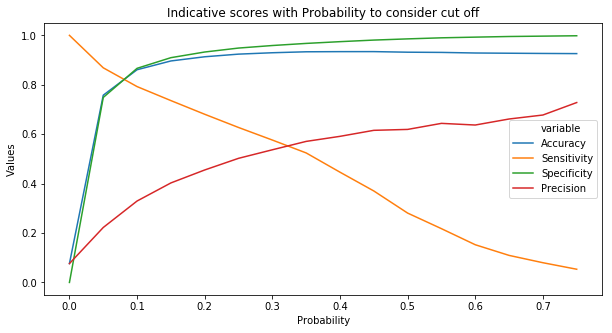

,Prob,Accuracy,Sensitivity,Specificity,Precision,TP,FN,TN,FP
0,0.00,0.076435,1.000000,0.000000,0.076435,1553.0,0.0,0.0,18765.0
1,0.05,0.757850,0.868641,0.748681,0.222424,1349.0,204.0,14049.0,4716.0
2,0.10,0.860912,0.792659,0.866560,0.329585,1231.0,322.0,16261.0,2504.0
3,0.15,0.896397,0.735995,0.909672,0.402748,1143.0,410.0,17070.0,1695.0
4,0.20,0.913328,0.680618,0.932587,0.455211,1057.0,496.0,17500.0,1265.0
5,0.25,0.924008,0.627173,0.948574,0.502321,974.0,579.0,17800.0,965.0
6,0.30,0.929619,0.576304,0.958860,0.536893,895.0,658.0,17993.0,772.0
7,0.35,0.933507,0.524147,0.967386,0.570827,814.0,739.0,18153.0,612.0
8,0.40,0.934098,0.446233,0.974474,0.591297,693.0,860.0,18286.0,479.0
9,0.45,0.934196,0.370251,0.980869,0.615632,575.0,978.0,18406.0,359.0


In [62]:
# Review with PCA Data Set

lm = LogisticRegression(C=10)
fit1 = lm.fit(X_train_PCA,y_train)
y_pred_prob = fit1.predict_proba(X_train_PCA)

def fun_optimal_probability(y_pred_prob,y_train):
    measures = pd.DataFrame(columns=["Prob","Accuracy","Sensitivity","Specificity","Precision","TP","FN","TN","FP"])
    #measures["cutof"] =np.arange(0,1,0.05)
    for i in np.arange(0,0.8,0.05):
        _altered_y = [1 if j >=i else 0 for j in y_pred_prob[:,1]]
        mat = confusion_matrix(y_train,_altered_y)
        tn, fp, fn, tp = mat.ravel()
        _accracy = (tn+tp) / (tn+tp+fn+fp)
        _sensitivity = tp / (tp+fn)
        _specificity =tn / (tn+fp)
        _precision = tp / (fp + tp)

        _item={"Prob":i,"Accuracy":_accracy,"Sensitivity":_sensitivity,"Specificity":_specificity,"Precision":_precision,"TP":tp,"FN":fn,"TN":tn,"FP":fp}
        measures=measures.append(_item,ignore_index=True )
    #print(_item)
    
    _temp =pd.melt( measures,id_vars=["Prob"],value_vars=["Accuracy","Sensitivity","Specificity","Precision"])

    plt.figure(figsize=(10,5))
    sns.lineplot(data = _temp,x="Prob",y="value",hue="variable")
    plt.title("Indicative scores with Probability to consider cut off")
    plt.xlabel("Probability")
    plt.ylabel("Values")
    plt.show()

    display(measures)
    
fun_optimal_probability(y_pred_prob,y_train)

### Review summary 

- Results of Logistic regression with PCA does not exhibit any improvement over and Logistic regression without PCA model at probability score of 0.1;
- While, the acuracy score is largely same, Sensitivity has come down in LR with PCA model. This is on account of increase of 80 counts under False Negative.

#### Tree Based Model 

- Decision tree implimentation (since decision tree does't required to scale the fields we will use unsclaed features)
- Random forest 
- Boosting classifications

In [63]:
# Decision tree model identify the best hyper parameters

models1 = {
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=100,min_samples_leaf=10)    
}

params1 = {
    'DecisionTreeClassifier': {'max_depth':[2,3,4],'min_samples_split' : [5,10,20]}  
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(train.drop("Target",axis=1),train.Target,scoring="recall", n_jobs=2) # decision tree does't required to scale the parameters

printmd(f"DecisionTreeClassifier identification of best hyper parameters")
helper1.score_summary()

Running GridSearchCV for DecisionTreeClassifier.
Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  45 out of  45 | elapsed:   37.7s finished


DecisionTreeClassifier identification of best hyper parameters

DecisionTreeClassifier


,estimator,min_score,mean_score,max_score,std_score,max_depth,min_samples_split
6,DecisionTreeClassifier,0.440514,0.462348,0.506452,0.0241505,4,5
7,DecisionTreeClassifier,0.440514,0.462348,0.506452,0.0241505,4,10
8,DecisionTreeClassifier,0.440514,0.462348,0.506452,0.0241505,4,20
0,DecisionTreeClassifier,0.429032,0.458469,0.490323,0.0220347,2,5
1,DecisionTreeClassifier,0.429032,0.458469,0.490323,0.0220347,2,10
2,DecisionTreeClassifier,0.429032,0.458469,0.490323,0.0220347,2,20
3,DecisionTreeClassifier,0.429032,0.458469,0.490323,0.0220347,3,5
4,DecisionTreeClassifier,0.429032,0.458469,0.490323,0.0220347,3,10
5,DecisionTreeClassifier,0.429032,0.458469,0.490323,0.0220347,3,20


### Review summary 

- After reviewing the DecisionTreeClassifier, we can see that the key differentiator is max_depth, where there is no change in min, max, mean and std_score, despite change in min_samples_split. He we will go ahead with max_depth =4 and min_samples_leaf = 5 and min_samples_split = 10 to arrive at the desired result.

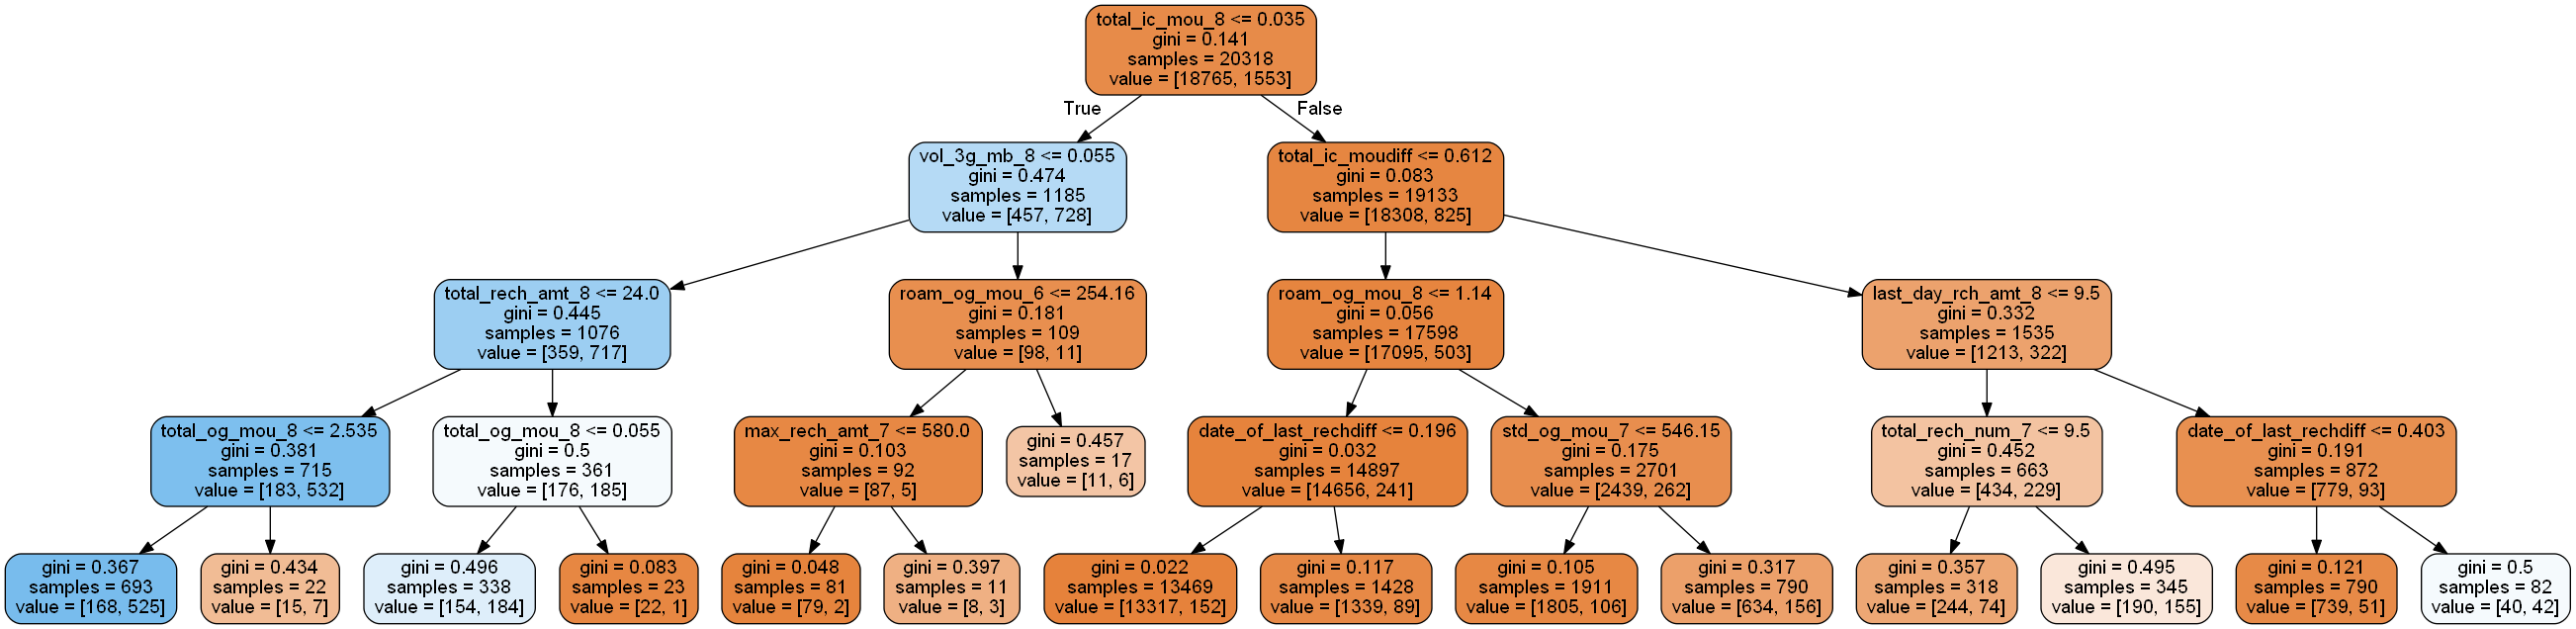

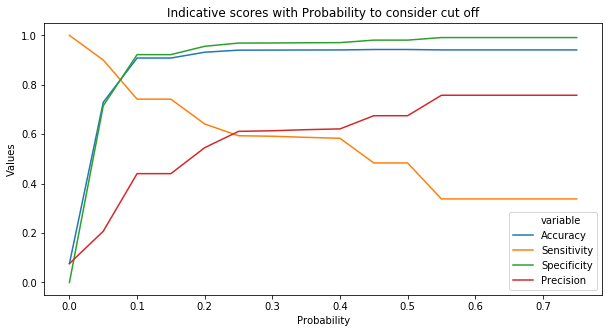

,Prob,Accuracy,Sensitivity,Specificity,Precision,TP,FN,TN,FP
0,0.00,0.076435,1.000000,0.000000,0.076435,1553.0,0.0,0.0,18765.0
1,0.05,0.729206,0.900193,0.715055,0.207265,1398.0,155.0,13418.0,5347.0
2,0.10,0.908209,0.741790,0.921982,0.440367,1152.0,401.0,17301.0,1464.0
3,0.15,0.908209,0.741790,0.921982,0.440367,1152.0,401.0,17301.0,1464.0
4,0.20,0.931735,0.641339,0.955769,0.545455,996.0,557.0,17935.0,830.0
5,0.25,0.940102,0.593690,0.968772,0.611406,922.0,631.0,18179.0,586.0
6,0.30,0.940348,0.591758,0.969198,0.613894,919.0,634.0,18187.0,578.0
7,0.35,0.940742,0.587250,0.969997,0.618305,912.0,641.0,18202.0,563.0
8,0.40,0.940988,0.583387,0.970584,0.621399,906.0,647.0,18213.0,552.0
9,0.45,0.942711,0.483580,0.980709,0.674753,751.0,802.0,18403.0,362.0


In [64]:
tr= DecisionTreeClassifier(random_state=100,min_samples_leaf=10,max_depth =4,min_samples_split=5)
fit = tr.fit(train.drop("Target",axis=1),train.Target)

# Putting features
features = list(train.drop("Target",axis=1).columns)

import os
os.environ["PATH"] += os.pathsep + f'D:/tools/release/bin'

dot_data = StringIO()  
export_graphviz(fit, out_file=dot_data,
                feature_names=features, filled=True,rounded=True)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
display(Image(graph.create_png()))

#display optimal probability 

fun_optimal_probability(fit.predict_proba(train.drop("Target",axis=1)),y_train)

### Summary of Decision Tree Analysis

- Post analysis of the result of decision tree method, we can see the precitor variables with maximum impact on churn probability;  
- Most important predictor variables are volume of 3G data, total recharge amount and total outgoing minutes of use. Declining trend in these 3 variables are indicator of high possibility of customer churn;  
- Model with probability Threshhold of 0.1 provides the best fit for training data set, where Accuracy = 73% and Sensitivity = 90%. At this threshold, we are not compromising between the two and the False Negative is at the minimum in terms of absolute value and so is True Negative;
- At this threshold, 1398 customers have been correctly predicted as churn and 13418 have been correctly predicted as non-churn; at the same time, 155 customers have been incorrectly predicted as not churn and 5347 incorrectly predcited as churn.



# Balancing data set among Target Classes 

- Since we have an imbalanced data, we will try to first balance the data set and then arrive at conclusions. We are using RandomOverSample technique to create random records for the churn data, or else it will cause overfitting

In [65]:
print(train.shape[0],train[train.Target==0].shape[0],train[train.Target==1].shape[0])

20318 18765 1553


In [66]:
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

sm = NearMiss(sampling_strategy ={0:6000,1:1553})
X_train_balanced,y_train_balanced = sm.fit_sample(X_train,y_train)
X_train_balanced = pd.DataFrame(X_train_balanced)
X_train_balanced.columns = X_train.columns 

y_train_balanced = pd.DataFrame(y_train_balanced)
y_train_balanced.columns = y_train.columns

printmd(f"### Shape of X_train {X_train_balanced.shape}")
printmd(f"### Shape of y_train {y_train_balanced.shape}")

printmd(f"### Churn Rate on Balanced Data Set {y_train_balanced[y_train_balanced.Target ==1].shape[0]/y_train_balanced.shape[0] }%")

### Shape of X_train (7553, 168)

### Shape of y_train (7553, 1)

### Churn Rate on Balanced Data Set 0.20561366344498874%

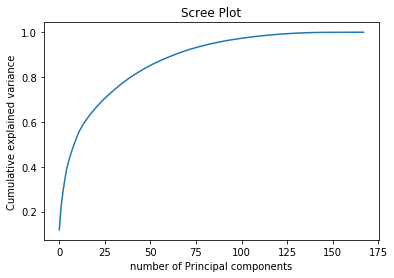

### Number of PC's explaining variation of 90% on the train data set is <font color='red'> 64 PC's </font>

In [87]:
pca = PCA()
np.random.RandomState(100)

pca.fit(X_train_balanced)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of Principal components')
plt.ylabel('Cumulative explained variance')
plt.savefig('pca_no')
plt.title("Scree Plot")
plt.show()

_no=len([i for i in list(np.cumsum(pca.explained_variance_ratio_)) if i <=0.90])

printmd(f"### Number of PC's explaining variation of 90% on the train data set is <font color='red'> {_no} PC's </font>")

In [68]:
pca = IncrementalPCA(n_components= 70, batch_size =100)

X_train_balanced_PCA = pd.DataFrame(pca.fit_transform(X_train_balanced))
X_test_balanced_PCA = pd.DataFrame(pca.transform(X_test))

In [69]:
#Logistic Regression with PCA Data Set

lm = LogisticRegression(C=10, class_weight='balanced')
fit1 = lm.fit(X_train_balanced_PCA,y_train_balanced)
y_pred_prob = fit1.predict(X_train_balanced_PCA)

#fun_optimal_probability(fit.predict_proba(X_train_balanced),y_train_balanced)



print(classification_report(y_pred_prob,y_train_balanced))

              precision    recall  f1-score   support

           0       0.82      0.95      0.88      5178
           1       0.83      0.54      0.66      2375

   micro avg       0.82      0.82      0.82      7553
   macro avg       0.82      0.75      0.77      7553
weighted avg       0.82      0.82      0.81      7553



### Random Forest on Balanced Data (comapring with Scaled Data Set vs PCA Data Set)

In [70]:
#  Balanced PCA Data Set

models1 = {
    'randomforest': RandomForestClassifier(random_state=100,min_samples_split=10,min_samples_leaf =5)    
}

params1 = {
    'randomforest': {'n_estimators': [100],
                    'max_depth':[2,3,4,6,8],
                    'class_weight':['balanced','balanced_subsample']}  
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(X_train_balanced_PCA,y_train_balanced,scoring="recall", n_jobs=4,cv=3)

helper1.score_summary()

Running GridSearchCV for randomforest.
Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


randomforest


[Parallel(n_jobs=4)]: Done  30 out of  30 | elapsed:   25.6s finished


,estimator,min_score,mean_score,max_score,std_score,class_weight,max_depth,n_estimators
0,randomforest,0.57529,0.696772,0.783366,0.0884564,balanced,2,100
5,randomforest,0.567568,0.69291,0.781431,0.0911088,balanced_subsample,2,100
1,randomforest,0.550193,0.670391,0.787234,0.0968006,balanced,3,100
6,randomforest,0.550193,0.669745,0.783366,0.0952846,balanced_subsample,3,100
2,randomforest,0.46332,0.6569,0.82205,0.147824,balanced,4,100
7,randomforest,0.467181,0.654964,0.814313,0.143135,balanced_subsample,4,100
3,randomforest,0.548263,0.634947,0.70793,0.0659002,balanced,6,100
8,randomforest,0.544402,0.621415,0.678917,0.0566222,balanced_subsample,6,100
4,randomforest,0.447876,0.569291,0.678917,0.0946895,balanced,8,100
9,randomforest,0.440154,0.567357,0.673114,0.0963068,balanced_subsample,8,100


In [71]:
# Random forest with the non PCA Data set Hyper Parameters tuning

models1 = {
    'randomforest': RandomForestClassifier(random_state=100,min_samples_split=10,min_samples_leaf =10)    
}

params1 = {
    'randomforest': {#'n_estimators': [100,200,500,1000],
                    'n_estimators': [100],
                    #'max_depth':[2,3,4,6,8],
                    'max_depth':[3],
                    'class_weight':['balanced','balanced_subsample']}  
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(X_train_balanced,y_train_balanced,scoring="recall", n_jobs=4,cv=5)

helper1.score_summary()

Running GridSearchCV for randomforest.
Fitting 5 folds for each of 2 candidates, totalling 10 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


randomforest


[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    6.2s finished


,estimator,min_score,mean_score,max_score,std_score,class_weight,max_depth,n_estimators
0,randomforest,0.412903,0.665609,0.906752,0.162336,balanced,3,100
1,randomforest,0.412903,0.663674,0.909968,0.163692,balanced_subsample,3,100


### Review summary 

- Both results with PCA and Non PCA provides similar results;
- We will take best fit hyper parameters arrived through non PCA data set and execute on the train and test data set

In [72]:
# using adaboosting 

# Random forest with the non PCA Data set Hyper Parameters tuning

models1 = {
    'RandomForestClassifier': RandomForestClassifier(random_state =100)    
}

params1 = {
    'RandomForestClassifier': {'n_estimators': [20,30,40,50],
                     'max_depth' :[2,3,5,7],
                     'min_samples_split' :[5,10,20,25],
                     'min_samples_leaf' :[5,10,20,25]
                     
                    }  
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(X_train,y_train,scoring="f1", n_jobs=4,cv=5)

helper1.score_summary()

Running GridSearchCV for RandomForestClassifier.
Fitting 5 folds for each of 256 candidates, totalling 1280 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   14.6s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  6.6min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed: 13.4min
[Parallel(n_jobs=4)]: Done 1280 out of 1280 | elapsed: 14.1min finished


RandomForestClassifier


,estimator,min_score,mean_score,max_score,std_score,max_depth,min_samples_leaf,min_samples_split,n_estimators
203,RandomForestClassifier,0.509804,0.527168,0.550898,0.0143485,7,5,20,50
219,RandomForestClassifier,0.51046,0.526303,0.544355,0.014038,7,10,20,50
211,RandomForestClassifier,0.51046,0.526303,0.544355,0.014038,7,10,5,50
215,RandomForestClassifier,0.51046,0.526303,0.544355,0.014038,7,10,10,50
210,RandomForestClassifier,0.509474,0.525819,0.544355,0.0122163,7,10,5,40
218,RandomForestClassifier,0.509474,0.525819,0.544355,0.0122163,7,10,20,40
214,RandomForestClassifier,0.509474,0.525819,0.544355,0.0122163,7,10,10,40
217,RandomForestClassifier,0.512605,0.524778,0.542169,0.00976487,7,10,20,30
213,RandomForestClassifier,0.512605,0.524778,0.542169,0.00976487,7,10,10,30
209,RandomForestClassifier,0.512605,0.524778,0.542169,0.00976487,7,10,5,30


In [74]:
# Random forest based on the above best hyper parameters

rf = RandomForestClassifier(random_state=100,min_samples_split=20,min_samples_leaf =10,n_estimators=20,max_depth=7,class_weight="balanced")    
fit =rf.fit(X_train_balanced,y_train_balanced)
y_predict = fit.predict(X_train_balanced)

printmd("### Training results")
print(classification_report(y_predict,y_train_balanced))

printmd("### Test Data Set results")
y_predict = fit.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      5655
           1       0.87      0.71      0.78      1898

   micro avg       0.90      0.90      0.90      7553
   macro avg       0.89      0.84      0.86      7553
weighted avg       0.90      0.90      0.90      7553



### Test Data Set results

              precision    recall  f1-score   support

           0       0.86      0.98      0.91      7031
           1       0.78      0.31      0.45      1677

   micro avg       0.85      0.85      0.85      8708
   macro avg       0.82      0.65      0.68      8708
weighted avg       0.84      0.85      0.82      8708



#### Review Summary 

- Random forest clearly indicates best fit with balanced data rather than imbalanced data;
- Random forest provides better results indicating scores of 91% f1 score, whereas, LR method only provided 88% score. F1 score is the harmoic mean of precision and recall score;
- Random forest indicates that maximum depth of 7 gives better results with "balanced_subsample" technieque.
- Random forest also indicates good results on 100 trees (n Estimator)
- <font color="red"> <b> Eventhough tried with different parameters to optmize the Random forest (max_depth and tree puning parameters) acuuracy scores on train and test scores are nearly same however recall on training data set indicating poor results</b></font>

- This problem we can address by adopting boosting techniques like xgboost and gradient boosting

### Boosting techniques

# <font color="red"> skip this block used for parameter findings </font>

In [66]:
# using adaboosting 

# Random forest with the non PCA Data set Hyper Parameters tuning

models1 = {
    'randomforest': AdaBoostClassifier(base_estimator =RandomForestClassifier(max_depth=1),random_state =100)    
}

params1 = {
    'randomforest': {#'n_estimators': [100,200,500,1000],
                    'n_estimators': [500]                    
                    }  
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(X_train_balanced,y_train_balanced,scoring="recall", n_jobs=4,cv=2)

helper1.score_summary()


Running GridSearchCV for randomforest.
Fitting 2 folds for each of 1 candidates, totalling 2 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


randomforest


[Parallel(n_jobs=4)]: Done   2 out of   2 | elapsed:   39.9s finished


,estimator,min_score,mean_score,max_score,std_score,n_estimators
0,randomforest,0.109395,0.37493,0.640464,0.265534,500


In [75]:
model_ada = AdaBoostClassifier(base_estimator =RandomForestClassifier(max_depth=1),random_state =100,n_estimators=30)    

model_ada_boosting_fit =model_ada.fit(X_train,y_train)

y_predict = model_ada_boosting_fit.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = model_ada_boosting_fit.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     19264
           1       0.44      0.65      0.53      1054

   micro avg       0.94      0.94      0.94     20318
   macro avg       0.71      0.80      0.75     20318
weighted avg       0.95      0.94      0.94     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      8242
           1       0.43      0.62      0.51       466

   micro avg       0.94      0.94      0.94      8708
   macro avg       0.70      0.79      0.74      8708
weighted avg       0.95      0.94      0.94      8708



# <font color="red"> skip this block used for parameter findings </font>

In [68]:
# using agradient boosting

# Random forest with the non PCA Data set Hyper Parameters tuning

models1 = {
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state =100)    
}

params1 = {
    'GradientBoostingClassifier': {'n_estimators': [10,20,40,50],
                     'max_depth' :[2,3,4,5],
                     'subsample' :[0.9]
                                          
                    }  
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(X_train,y_train,scoring="f1", n_jobs=4,cv=5)

helper1.score_summary()


Running GridSearchCV for GradientBoostingClassifier.
Fitting 5 folds for each of 16 candidates, totalling 80 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done  80 out of  80 | elapsed:  5.2min finished


GradientBoostingClassifier


,estimator,min_score,mean_score,max_score,std_score,max_depth,n_estimators,subsample
11,GradientBoostingClassifier,0.564103,0.582095,0.613971,0.017354,4,50,0.9
15,GradientBoostingClassifier,0.55914,0.581366,0.599641,0.0171986,5,50,0.9
14,GradientBoostingClassifier,0.558559,0.576963,0.605839,0.018056,5,40,0.9
10,GradientBoostingClassifier,0.558824,0.575989,0.605505,0.0159711,4,40,0.9
7,GradientBoostingClassifier,0.541744,0.56868,0.595903,0.0172047,3,50,0.9
6,GradientBoostingClassifier,0.544776,0.560551,0.577519,0.0138361,3,40,0.9
13,GradientBoostingClassifier,0.525097,0.544565,0.559055,0.0136926,5,20,0.9
3,GradientBoostingClassifier,0.514056,0.539,0.568588,0.0186804,2,50,0.9
2,GradientBoostingClassifier,0.509165,0.529023,0.541833,0.0114665,2,40,0.9
9,GradientBoostingClassifier,0.494888,0.522541,0.546185,0.01723,4,20,0.9


In [76]:
#model_gradient_fit

model_gradient = GradientBoostingClassifier(n_estimators=50,random_state =150,max_depth =3,subsample =0.9)    

model_gradient_fit =model_gradient.fit(X_train,y_train)

y_predict = model_gradient_fit.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = model_gradient_fit.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     19189
           1       0.52      0.72      0.61      1129

   micro avg       0.95      0.95      0.95     20318
   macro avg       0.75      0.84      0.79     20318
weighted avg       0.96      0.95      0.95     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      8215
           1       0.49      0.67      0.56       493

   micro avg       0.94      0.94      0.94      8708
   macro avg       0.73      0.81      0.77      8708
weighted avg       0.95      0.94      0.95      8708



# <font color="red"> skip this block used for parameter findings </font>

In [70]:
# using xboost classifier

# Random forest with the non PCA Data set Hyper Parameters tuning

models1 = {
    'XGBClassifier': XGBClassifier(random_state =100,base_score=0.6,objective = 'binary:logistic')    
}

params1 = {
    'XGBClassifier': {'n_estimators': [10,20,40,50],
                     'max_depth' :[2,3,4,5],
                     'subsample' :[0.9],
                     'learning_rate' :[0.3],
                     'reg_alpha' :[3],
                     'colsample_bytree': [0.5]
                     
                    }  
}

helper1 = EstimatorSelectionHelper(models1, params1)
helper1.fit(X_train,y_train,scoring="f1", n_jobs=4,cv=5)

helper1.score_summary()


Running GridSearchCV for XGBClassifier.
Fitting 5 folds for each of 16 candidates, totalling 80 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.4min


XGBClassifier


[Parallel(n_jobs=4)]: Done  80 out of  80 | elapsed:  3.2min finished


,estimator,min_score,mean_score,max_score,std_score,colsample_bytree,learning_rate,max_depth,n_estimators,reg_alpha,subsample
14,XGBClassifier,0.556169,0.589846,0.630996,0.0328155,0.5,0.3,5,40,3,0.9
10,XGBClassifier,0.559567,0.589496,0.619308,0.0224045,0.5,0.3,4,40,3,0.9
7,XGBClassifier,0.565217,0.583128,0.604736,0.0163104,0.5,0.3,3,50,3,0.9
15,XGBClassifier,0.54479,0.579179,0.615385,0.0298759,0.5,0.3,5,50,3,0.9
11,XGBClassifier,0.557377,0.577835,0.603978,0.0204874,0.5,0.3,4,50,3,0.9
13,XGBClassifier,0.565056,0.575917,0.594796,0.0131469,0.5,0.3,5,20,3,0.9
6,XGBClassifier,0.554529,0.575251,0.604396,0.0202588,0.5,0.3,3,40,3,0.9
9,XGBClassifier,0.551471,0.570511,0.589552,0.0149557,0.5,0.3,4,20,3,0.9
12,XGBClassifier,0.535373,0.561501,0.602637,0.0257641,0.5,0.3,5,10,3,0.9
3,XGBClassifier,0.531073,0.560992,0.59887,0.025361,0.5,0.3,2,50,3,0.9


In [77]:
model_XGBClassifier = XGBClassifier(n_estimators=40,random_state =150,max_depth =3,subsample =0.7,learning_rate=0.3,reg_alpha =5,colsample_bytree  =0.5,                                    
                                   objective = 'binary:logistic')    

model_XGBClassifier_fit =model_XGBClassifier.fit(X_train,y_train)

y_predict = model_XGBClassifier_fit.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = model_XGBClassifier_fit.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     19114
           1       0.56      0.73      0.63      1204

   micro avg       0.95      0.95      0.95     20318
   macro avg       0.77      0.85      0.80     20318
weighted avg       0.96      0.95      0.95     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      8180
           1       0.51      0.65      0.57       528

   micro avg       0.94      0.94      0.94      8708
   macro avg       0.74      0.81      0.77      8708
weighted avg       0.95      0.94      0.94      8708



In [78]:
# Random forest based on the above best hyper parameters

rf = RandomForestClassifier(random_state=100,min_samples_split=20,min_samples_leaf =10,n_estimators=20,max_depth=7,class_weight="balanced")    
rf_fit =rf.fit(X_train,y_train)
y_predict = rf_fit.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = rf_fit.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     17720
           1       0.85      0.51      0.64      2598

   micro avg       0.93      0.93      0.93     20318
   macro avg       0.89      0.75      0.80     20318
weighted avg       0.92      0.93      0.92     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7601
           1       0.76      0.46      0.57      1107

   micro avg       0.91      0.91      0.91      8708
   macro avg       0.84      0.72      0.76      8708
weighted avg       0.90      0.91      0.90      8708



In [79]:
model_SVC = SVC(kernel ="linear",class_weight ="balanced",max_iter =20,random_state =100,probability=True)    

model_SVC_fit =model_SVC.fit(X_train,y_train)

y_predict = model_SVC_fit.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = model_SVC_fit.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.35      0.97      0.51      6743
           1       0.85      0.10      0.17     13575

   micro avg       0.39      0.39      0.39     20318
   macro avg       0.60      0.53      0.34     20318
weighted avg       0.68      0.39      0.29     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.35      0.96      0.51      2887
           1       0.84      0.10      0.17      5821

   micro avg       0.38      0.38      0.38      8708
   macro avg       0.59      0.53      0.34      8708
weighted avg       0.67      0.38      0.28      8708



In [80]:
lm = LogisticRegression(C=1)    

model_lm =lm.fit(X_train,y_train)

y_predict = model_lm.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = lm.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     19544
           1       0.32      0.65      0.43       774

   micro avg       0.93      0.93      0.93     20318
   macro avg       0.65      0.80      0.70     20318
weighted avg       0.96      0.93      0.95     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      8379
           1       0.29      0.59      0.39       329

   micro avg       0.93      0.93      0.93      8708
   macro avg       0.64      0.77      0.67      8708
weighted avg       0.96      0.93      0.94      8708



In [81]:
model_dr = DecisionTreeClassifier(random_state=100,min_samples_leaf=10,max_depth =4,min_samples_split=5)

model_dr_fit =model_dr.fit(X_train,y_train)

y_predict = model_dr_fit.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = model_dr_fit.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     19205
           1       0.48      0.67      0.56      1113

   micro avg       0.94      0.94      0.94     20318
   macro avg       0.73      0.82      0.77     20318
weighted avg       0.95      0.94      0.95     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      8237
           1       0.45      0.64      0.53       471

   micro avg       0.94      0.94      0.94      8708
   macro avg       0.71      0.80      0.75      8708
weighted avg       0.95      0.94      0.94      8708



# MODEL of Models

Using voting classifier

In [82]:
from sklearn.ensemble import VotingClassifier
eclf1 = VotingClassifier(estimators=[("model_dr_fit",model_dr_fit),("model_lm",model_lm),("svr",model_SVC_fit),('rf', rf_fit), ('ada', model_ada_boosting_fit), ('gradient', model_gradient_fit),("xgboost",model_XGBClassifier_fit)],
                         weights = [1,1,1,2,2,3,4], voting='hard')
eclf1 = eclf1.fit(X_test, y_test)


y_predict = eclf1.predict(X_train)

printmd("### Training results")
print(classification_report(y_predict,y_train))

printmd("### Test Data Set results")
y_predict = eclf1.predict(X_test)
print(classification_report(y_predict,y_test))

### Training results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     19204
           1       0.48      0.67      0.56      1114

   micro avg       0.94      0.94      0.94     20318
   macro avg       0.73      0.81      0.76     20318
weighted avg       0.95      0.94      0.95     20318



### Test Data Set results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      8195
           1       0.57      0.75      0.65       513

   micro avg       0.95      0.95      0.95      8708
   macro avg       0.78      0.86      0.81      8708
weighted avg       0.96      0.95      0.96      8708



In [83]:
#model_XGBClassifier_fit.feature_importances_

_col =pd.DataFrame(X_train.columns)
_col.columns=["name"]
_col["imp"] =model_XGBClassifier_fit.feature_importances_

_col.sort_values(by="imp",ascending=False).iloc[:20,].name

80          total_ic_mou_8
156     total_rech_amtdiff
152       total_ic_moudiff
145     loc_ic_t2m_moudiff
147         loc_ic_moudiff
59        loc_ic_t2m_mou_8
61        loc_ic_t2f_mou_7
102     last_day_rch_amt_8
14           roam_og_mou_8
143       total_og_moudiff
53          total_og_mou_8
105            vol_2g_mb_8
60        loc_ic_t2f_mou_6
27            loc_og_mou_6
13           roam_og_mou_7
2                   arpu_8
40            std_og_mou_7
41            std_og_mou_8
65            loc_ic_mou_8
99     date_of_last_rech_8
Name: name, dtype: object

In [84]:
from sklearn.metrics import f1_score

In [85]:
f1_score(y_train,model_XGBClassifier_fit.predict(X_train))

0.6340224882118244

In [86]:
f1_score(y_test,model_XGBClassifier_fit.predict(X_test))

0.5745212323064113

#### Inferences and Recommendations
We have run the cleaned data on both the balanced and imbalanced dataset. As we have seen before balanced dataset has yielded better results. This balanced datset has been modelled using Logistic Regression and Tree Models. The latter has been further enhanced using boosting techniques and we have decided to go ahead with XG Boosting on account of the inherent benefits in using this technique. Based on the results given by the voting classifier, the following atributes have been found to be of importance and can be recommended to the telecom company as a precursor to customer churning. The 10 predictor variables in descending order w.r.t. relative importance is given below:

1. total_ic_mou_8
2. total_rech_amtdiff (derived feature)
3. total_ic_moudiff (derived feature)
4. loc_ic_t2m_moudiff (derived feature)
5. loc_ic_moudiff (derived feature)
6. loc_ic_t2m_mou_8
7. loc_ic_t2f_mou_7
8. last_day_rch_amt_8
9. roam_og_mou_8
10.total_og_moudiff